# Lab Four: Multi-layer Perceptron

Team Members: Zi Ling, David Guo

## 1. Data Preparation

#### 1.1 Loading and Removing Missing Data

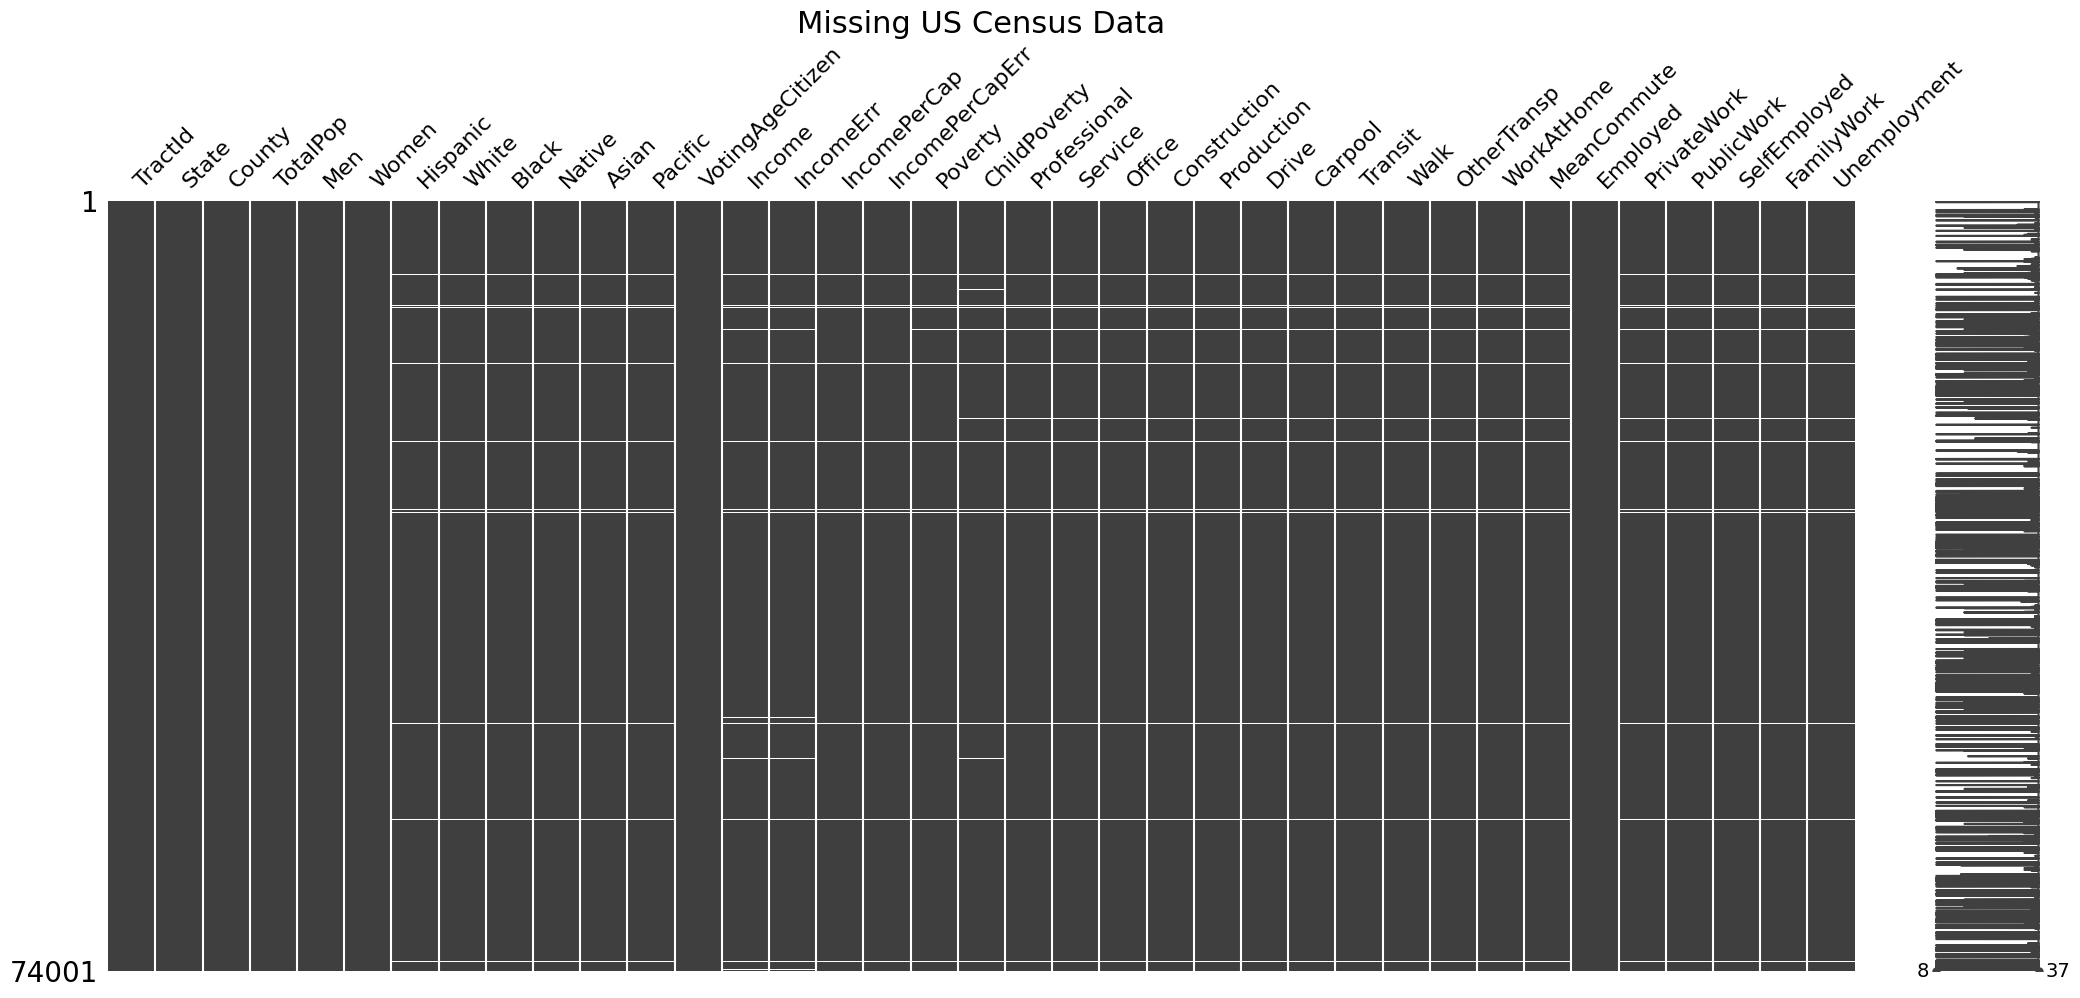

<Figure size 640x480 with 0 Axes>

TractId             0.000000
State               0.000000
County              0.000000
TotalPop            0.000000
Men                 0.000000
Women               0.000000
Hispanic            0.940528
White               0.940528
Black               0.940528
Native              0.940528
Asian               0.940528
Pacific             0.940528
VotingAgeCitizen    0.000000
Income              1.508088
IncomeErr           1.508088
IncomePerCap        1.006743
IncomePerCapErr     1.006743
Poverty             1.137822
ChildPoverty        1.499980
Professional        1.095931
Service             1.095931
Office              1.095931
Construction        1.095931
Production          1.095931
Drive               1.082418
Carpool             1.082418
Transit             1.082418
Walk                1.082418
OtherTransp         1.082418
WorkAtHome          1.082418
MeanCommute         1.278361
Employed            0.000000
PrivateWork         1.095931
PublicWork          1.095931
SelfEmployed  

In [1]:
import pandas as pd
import missingno as mn
import matplotlib.pyplot as plt

df = pd.read_csv("acs2017_census_tract_data.csv")

def visualizedMissingMatrix(df, title):
	mn.matrix(df)
	plt.title(title,fontsize=22)

	plt.figure()
	plt.show()

visualizedMissingMatrix(df, "Missing US Census Data")
print((df.isnull().sum()/df.shape[0]) * 100)

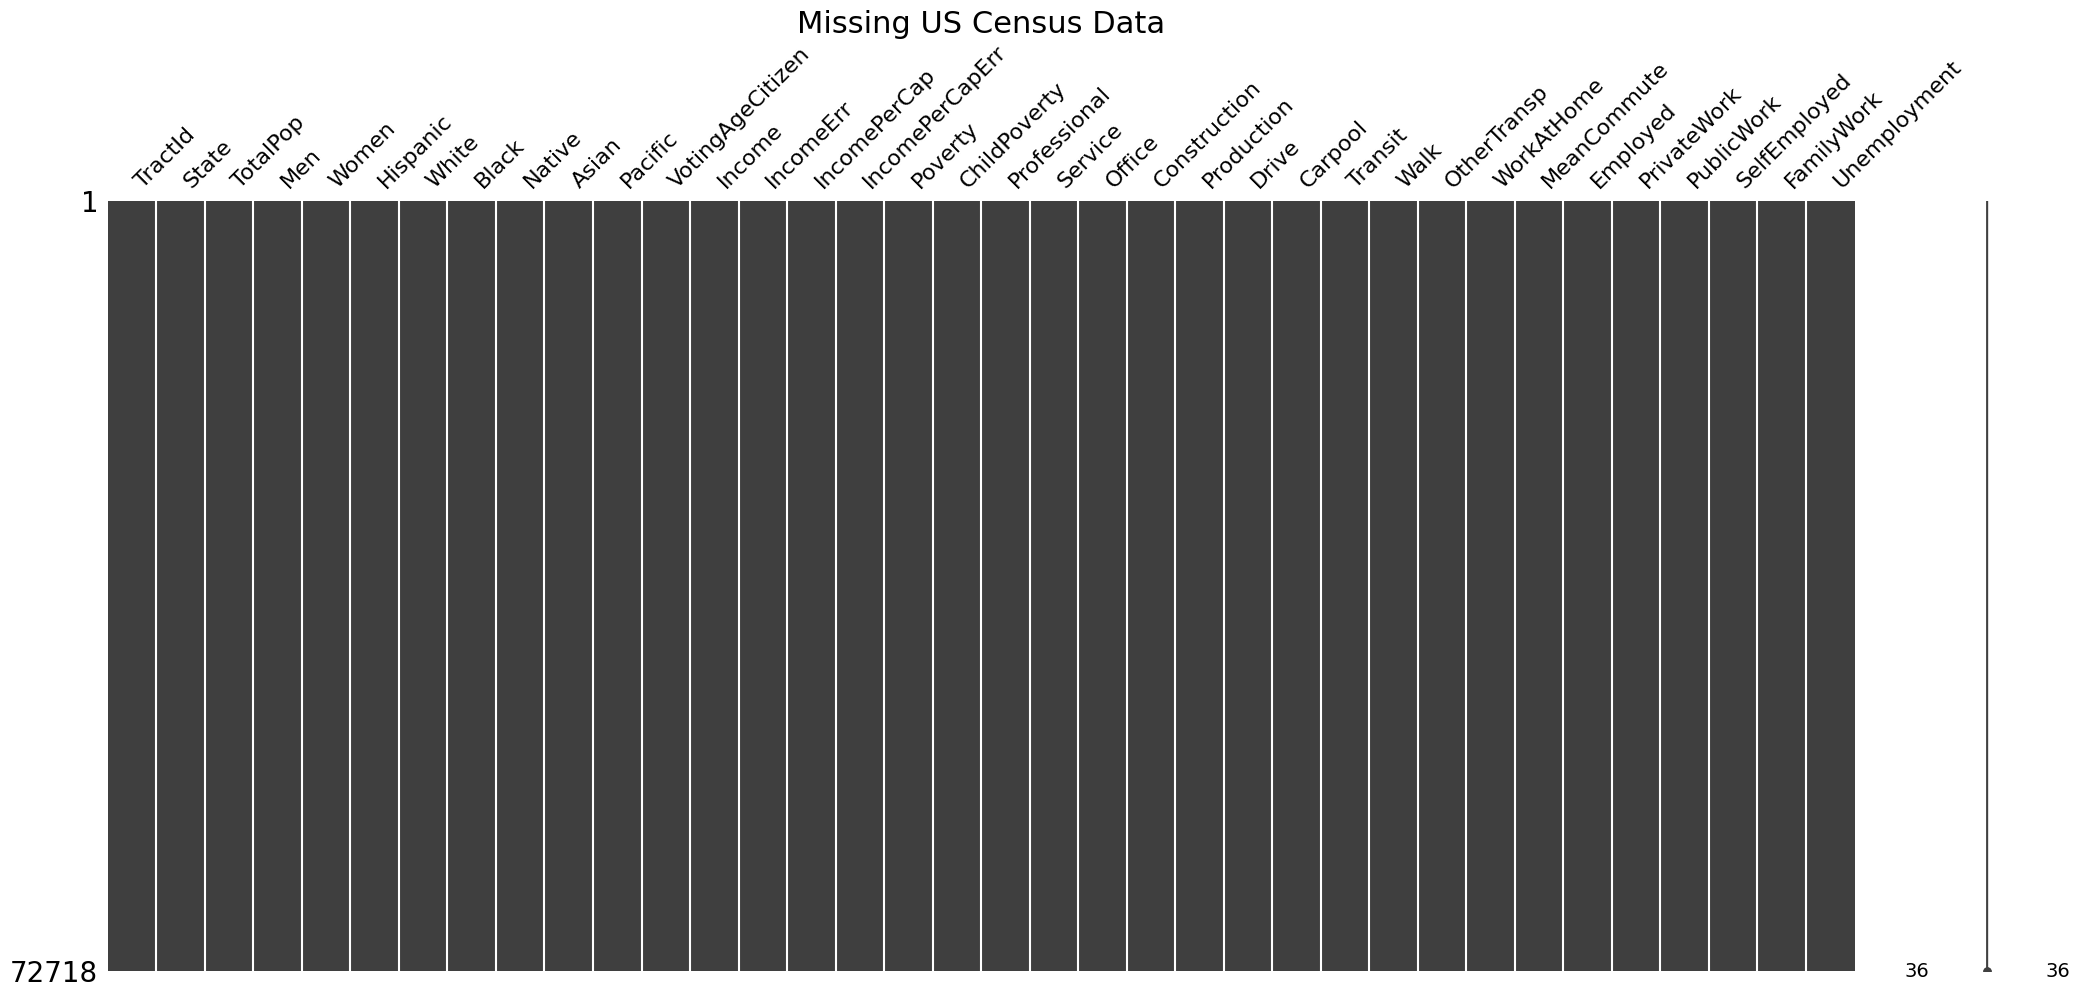

<Figure size 640x480 with 0 Axes>

<class 'pandas.core.frame.DataFrame'>
Index: 72718 entries, 0 to 74000
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   TractId           72718 non-null  int64  
 1   State             72718 non-null  int64  
 2   TotalPop          72718 non-null  int64  
 3   Men               72718 non-null  int64  
 4   Women             72718 non-null  int64  
 5   Hispanic          72718 non-null  float64
 6   White             72718 non-null  float64
 7   Black             72718 non-null  float64
 8   Native            72718 non-null  float64
 9   Asian             72718 non-null  float64
 10  Pacific           72718 non-null  float64
 11  VotingAgeCitizen  72718 non-null  int64  
 12  Income            72718 non-null  float64
 13  IncomeErr         72718 non-null  float64
 14  IncomePerCap      72718 non-null  float64
 15  IncomePerCapErr   72718 non-null  float64
 16  Poverty           72718 non-null  float64
 17

In [2]:
from sklearn.preprocessing import LabelEncoder

state_encoder = LabelEncoder()

df = df.dropna()

state_encoder.fit(df["State"])
df["State"] = state_encoder.transform(df["State"])
df = df.drop("County", axis=1)

visualizedMissingMatrix(df, "Missing US Census Data")
df.info()

So far, what we have done is load the dataset in to the pandas data frame, and remove duplicate values. We are using the label encoder method from scikit learn so that we can later decode it back to the string and perform a one hot encoding. 

We have decided to remove the county feature as we have an income feature. Since income is tied to the parent, a child living in a higher income household is more likely to be above the poverty line, and vice versa. As such the performance of the model should not drastically changed if we remove the county feature, and also speed up the training of the model as performing a hot hot encoding would create many feature, which could slow down the model training.

### 1.2 Balancing and Splitting The Dataset

In [3]:
#Dividing the dataset in to 4 equal parts
df['ChildPovertyClass'] = pd.qcut(df['ChildPoverty'], q=4, labels=False)
df['ChildPovertyClass'].value_counts()

ChildPovertyClass
0    18229
1    18171
3    18170
2    18148
Name: count, dtype: int64

Since we are creating 4 classes for the child poverty feature, we can use qcut from pandas to quantized the classes equally in to 4 classes. This ensures that each bins have the same number of classes. 

From the result, we can see that it is fairly equal between all classes. While there are some classes that has more than other, but the different is small so that it would not skew the result much.

Balancing should be done on the training set so that it can be trained equally over each class, otherwise we could be overfitting the model to a certain class instead. The test set should be left as is not all the data we get are equally distributed among each class.

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['ChildPoverty', 'ChildPovertyClass'])
y = df['ChildPovertyClass']

X_train, X_test, y_train, y_test = train_test_split(
	X, y,
	test_size=0.2,
	random_state=42,
	stratify=y
)


## 2. Pre Processing, and Initial Modeling.

### Combing the Class Into One

In [5]:
#Asked GPT to help with combing the TwoLayerPerceptronBase, TLPMiniBatch, TLPMiniBatchCrossEntropy, and TLPBetterInitial into one class for easy readability, and debugging

from sklearn.metrics import accuracy_score
import numpy as np
from scipy.special import expit
import pandas as pd
import sys

class TwoLayerPerceptron:
	def __init__(self, n_hidden=30, C=0.0, epochs=500, eta=0.001, 
				 random_state=None, shuffle=True, minibatches=1):
		np.random.seed(random_state)
		self.n_hidden = n_hidden
		self.l2_C = C
		self.epochs = epochs
		self.eta = eta
		self.shuffle = shuffle
		self.minibatches = minibatches
		
	@staticmethod
	def _encode_labels(y):
		"""Encode labels into one-hot representation"""
		onehot = pd.get_dummies(y).values.T
		return onehot

	def _initialize_weights(self):
		"""Initialize weights Glorot and He normalization."""
		init_bound = 4*np.sqrt(6. / (self.n_hidden + self.n_features_))
		W1 = np.random.uniform(-init_bound, init_bound, (self.n_hidden, self.n_features_))

		# reduce the final layer magnitude in order to balance the size of the gradients
		init_bound = 4*np.sqrt(6 / (self.n_output_ + self.n_hidden))
		W2 = np.random.uniform(-init_bound, init_bound, (self.n_output_, self.n_hidden)) 
		
		# set these to zero to start so that
		# they do not immediately saturate the neurons
		b1 = np.zeros((self.n_hidden, 1))
		b2 = np.zeros((self.n_output_, 1)) - 2.0  # ensure stays about zero mean
		
		return W1, W2, b1, b2
	
	@staticmethod
	def _sigmoid(z):
		"""Use scipy.special.expit to avoid overflow"""
		return expit(z)
	
	@staticmethod
	def _L2_reg(lambda_, W1, W2):
		"""Compute L2-regularization cost"""
		return (lambda_/2.0) * np.sqrt(np.mean(W1 ** 2) + np.mean(W2 ** 2))
	
	def _cost(self, A3, Y_enc, W1, W2):
		"""Get the cross-entropy objective function value"""
		cost = -np.mean(np.nan_to_num((Y_enc*np.log(A3+1e-7)+(1-Y_enc)*np.log(1-A3+1e-7))))
		L2_term = self._L2_reg(self.l2_C, W1, W2)
		return cost + L2_term
	
	def _feedforward(self, X, W1, W2, b1, b2):
		"""Compute feedforward step"""
		A1 = X.T
		Z1 = W1 @ A1 + b1
		A2 = self._sigmoid(Z1)
		Z2 = W2 @ A2 + b2
		A3 = self._sigmoid(Z2)
		return A1, Z1, A2, Z2, A3
	
	def _get_gradient(self, A1, A2, A3, Z1, Z2, Y_enc, W1, W2):
		"""Compute gradient step using vectorized backpropagation with cross-entropy loss."""
		# Vectorized backpropagation for cross-entropy
		V2 = (A3 - Y_enc)
		V1 = A2 * (1 - A2) * (W2.T @ V2)
		
		gradW2 = V2 @ A2.T
		gradW1 = V1 @ A1.T
		
		gradb2 = np.sum(V2, axis=1).reshape((-1, 1))
		gradb1 = np.sum(V1, axis=1).reshape((-1, 1))
		
		# Regularize weights that are not bias terms
		gradW1 += W1 * self.l2_C
		gradW2 += W2 * self.l2_C

		return gradW1, gradW2, gradb1, gradb2
	
	def _update_parameters(self, eta, gradW1, gradW2, gradb1, gradb2):
		"""Update weights using gradient descent"""
		self.W1 -= eta * gradW1
		self.W2 -= eta * gradW2
		self.b1 -= eta * gradb1
		self.b2 -= eta * gradb2
	
	def fit(self, X, y, print_progress=False, XY_test=None):
		"""Learn weights from training data with mini-batch"""
		X_data, y_data = X.copy(), y.copy()
		X_data = np.array(X_data)
		y_data = np.array(y_data)
		Y_enc = self._encode_labels(y)
		
		# Init weights and setup matrices
		self.n_features_ = X_data.shape[1]
		self.n_output_ = Y_enc.shape[0]

		if not hasattr(self, 'W1'):
			self.W1, self.W2, self.b1, self.b2 = self._initialize_weights()

		self.cost_ = []
		self.score_ = []
		self.score_.append(accuracy_score(y_data, self.predict(X_data)))
		
		# Keep track of validation, if given
		if XY_test is not None:
			X_test = XY_test[0].copy()
			y_test = XY_test[1].copy()
			self.val_score_ = []
			self.val_score_.append(accuracy_score(y_test, self.predict(X_test)))
			self.val_cost_ = []
			
		for i in range(self.epochs):
			if print_progress > 0 and (i + 1) % print_progress == 0:
				sys.stderr.write('\rEpoch: %d/%d' % (i + 1, self.epochs))
				sys.stderr.flush()

			if self.shuffle:
				idx_shuffle = np.random.permutation(y_data.shape[0])
				X_data, Y_enc, y_data = X_data[idx_shuffle], Y_enc[:, idx_shuffle], y_data[idx_shuffle]

			mini = np.array_split(range(y_data.shape[0]), self.minibatches)
			mini_cost = []
			
			for idx in mini:
				# Feedforward
				A1, Z1, A2, Z2, A3 = self._feedforward(X_data[idx], self.W1, 
														 self.W2, self.b1, self.b2)
				
				cost = self._cost(A3, Y_enc[:, idx], self.W1, self.W2)
				mini_cost.append(cost)

				# Compute gradient via backpropagation
				gradW1, gradW2, gradb1, gradb2 = self._get_gradient(
					A1=A1, A2=A2, A3=A3, Z1=Z1, Z2=Z2, 
					Y_enc=Y_enc[:, idx], W1=self.W1, W2=self.W2
				)
				
				# Update all W and b values
				self._update_parameters(self.eta, gradW1, gradW2, gradb1, gradb2)

			self.cost_.append(np.mean(mini_cost))
			self.score_.append(accuracy_score(y_data, self.predict(X_data)))
			
			# Update if a validation set was provided
			if XY_test is not None:
				yhat = self.predict(X_test)
				self.val_score_.append(accuracy_score(y_test, yhat))
			
		return self
	
	def predict(self, X):
		"""Predict class labels"""
		_, _, _, _, A3 = self._feedforward(X, self.W1, self.W2, self.b1, self.b2)
		y_pred = np.argmax(A3, axis=0)
		return y_pred

### 2.1 Model Analysis on non normalize dataset

Training Accuracy: 0.24956165984804207
Test Accuracy: 0.2495874587458746


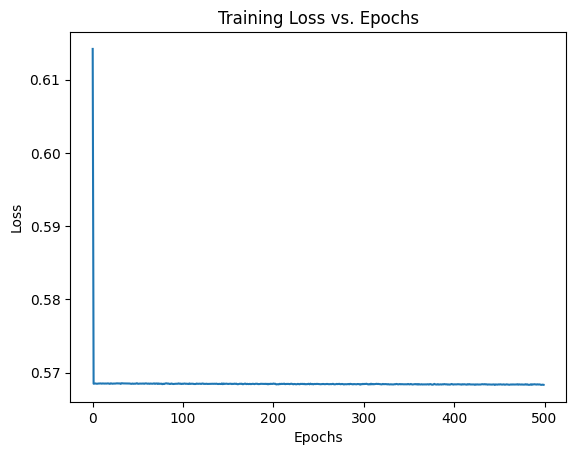

In [6]:
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

nn_params_dict = {
	'n_hidden': 30,
	'C': 0.01,
	'epochs': 500,
	'eta': 0.0001,
	'random_state': 42,
	'shuffle': True,
	'minibatches': 50
}

two_layer_nn_model1 = TwoLayerPerceptron(**nn_params_dict)
two_layer_nn_model1.fit(X_train, y_train)

y_train_pred_model1 = two_layer_nn_model1.predict(X_train)
train_acc_model1 = accuracy_score(y_train, y_train_pred_model1)
print("Training Accuracy:", train_acc_model1)

y_test_pred_model1 = two_layer_nn_model1.predict(X_test)
test_acc_model1 = accuracy_score(y_test, y_test_pred_model1)
print("Test Accuracy:", test_acc_model1)

plt.plot(range(len(two_layer_nn_model1.cost_)), two_layer_nn_model1.cost_)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs. Epochs')
plt.show()

Looking at the graph, it is converging, albeit rapidly. It starts around 0.600 and then it flattens around .550, but it starts to flatten around 3-5 epochs indicating that it is difficult to deal with raw data. 

### 2.2 Model Analysis on Normalize Dataset

Trained Accuracy 0.7354488259359852
Test Accuracy: 0.7282040704070407


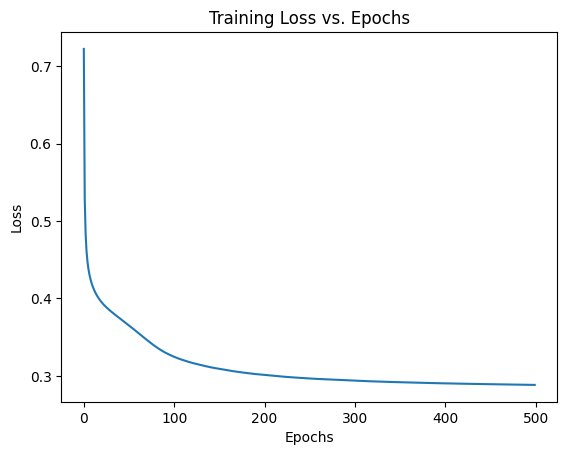

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

two_layer_nn_model2 = TwoLayerPerceptron(**nn_params_dict)
two_layer_nn_model2.fit(X_train_scaled, y_train)

y_train_predict_model2 = two_layer_nn_model2.predict(X_train_scaled)
train_acc_model2 = accuracy_score(y_train, y_train_predict_model2)
print("Trained Accuracy", train_acc_model2)

y_test_pred_model2 = two_layer_nn_model2.predict(X_test_scaled)
test_acc_model2 = accuracy_score(y_test, y_test_pred_model2)
print("Test Accuracy:", test_acc_model2)

plt.plot(range(len(two_layer_nn_model2.cost_)), two_layer_nn_model2.cost_)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs. Epochs')
plt.show()

After normalizing the dataset, the model had good convergence around 300 epochs. Initially it had a 0.65 loss, but was able to converge to a around 0.27. This shows that model was able to train well on our dataset with around 73% accuracy. Running the model longer on epoch could result in a better result, but due to computation limitation, we restricted it to around 400 epochs. 

### 2.3 Model Analysis on Normalize, and one hot encode Dataset

In [8]:
X_train["State"] = state_encoder.inverse_transform(X_train["State"])
X_test["State"] = state_encoder.inverse_transform(X_test["State"])

print("Train State Column", X_train["State"])
print("Test State Column", X_test["State"])

Train State Column 69679       Washington
71657        Wisconsin
31410    Massachusetts
68825         Virginia
73758      Puerto Rico
             ...      
11670         Colorado
26752           Kansas
53365             Ohio
56753     Pennsylvania
8917        California
Name: State, Length: 58174, dtype: object
Test State Column 48295    North Carolina
62822             Texas
60867         Tennessee
59830    South Carolina
24802           Indiana
              ...      
71188     West Virginia
22228          Illinois
24587           Indiana
29135         Louisiana
52164              Ohio
Name: State, Length: 14544, dtype: object


In [9]:
X_train_one_hot = X_train.copy()
X_test_one_hot = X_test.copy()

X_train_one_hot = pd.get_dummies(X_train_one_hot, columns=["State"], dtype=int)
X_test_one_hot = pd.get_dummies(X_test_one_hot, columns=["State"], dtype=int)

##Aligning them as GPT mention that it could create a misaligned when performing encoding on a split. 
X_train_encoded, X_test_encoded = X_train_one_hot.align(X_test_one_hot, join='left', axis=1, fill_value=0)


In [10]:
X_train_scaled_encoded = scaler.fit_transform(X_train_encoded)
X_test_scaled_encoded = scaler.fit_transform(X_test_encoded)

Trained Accuracy 0.7369271495857256
Test Accuracy: 0.7242161716171617


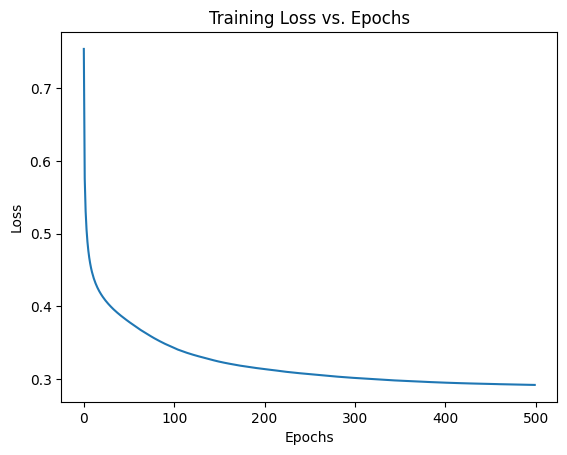

In [11]:
two_layer_nn_model3 = TwoLayerPerceptron(**nn_params_dict)
two_layer_nn_model3.fit(X_train_scaled_encoded, y_train)

y_train_predict_model3 = two_layer_nn_model3.predict(X_train_scaled_encoded)
train_acc_model3 = accuracy_score(y_train, y_train_predict_model3)
print("Trained Accuracy", train_acc_model3)

y_test_pred_model3 = two_layer_nn_model3.predict(X_test_scaled_encoded)
test_acc_model3 = accuracy_score(y_test, y_test_pred_model3)
print("Test Accuracy:", test_acc_model3)

plt.plot(range(len(two_layer_nn_model3.cost_)), two_layer_nn_model3.cost_)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs. Epochs')
plt.show()

After performing one hot encoding, and normalizing the dataset, we were able to achieve good convergence, but modest accuracy of 72% for the test accuracy. The model starts flattening around 450 epochs. While the initial loss was around 73%, it started to converge with a loss around 23% indicating that the model was able to be better trained on a normalized dataset. 

However, model 2, and model 3 almost performed identical in terms of accuracy, the convergence of the loss is more smoother than model 2, showing that one hot encoding is better suited for the model. 

#### 2.4 Analysis of the three model. 

<!-- We ran all three models with the same parameters. From the results, we can clearly see the one that has raw data performed the worst out of all of them. It was some what flattening, but we can still see that it was jagged, so it did converge correctly either. However, doing normalization/standardizing the continuous data, it performed much better with a better looking convergence graph, and a better accuracy. This is because neural network is sensitive to the input data, and if there are outliers in the data set then it struggles to train the model. 

However, if we normalized the data it performed a lot better indicating that normilaztoin is important when training the neural network since it yielded a good result. 

When comparing both model 2, and 3 model 3 started off with a lower loss value compared to model 2 0.50 and 0.65 respectively, indicating that one hot encoding did a yield a better initial training compared to not doing one hot encoding. Additionally, model 3 did result in a higher accuracy compared to model 2 75% and 74% respectively, but the training time became much more computational. Since we decided to keep the county column, and one hot encode it, the features that it was trained on increased as well resulting in a higher computation time. 

If we want to get the best model, then one hot encoding is the way to go to get the best possible accuracy score.  -->



{ 'model1': { 'model2': {'p_value': 0.0, 'statistic': 1106.0},
              'model3': {'p_value': 0.0, 'statistic': 1165.0}},
  'model2': {'model3': {'p_value': 0.06717081369597643, 'statistic': 456.0}}}


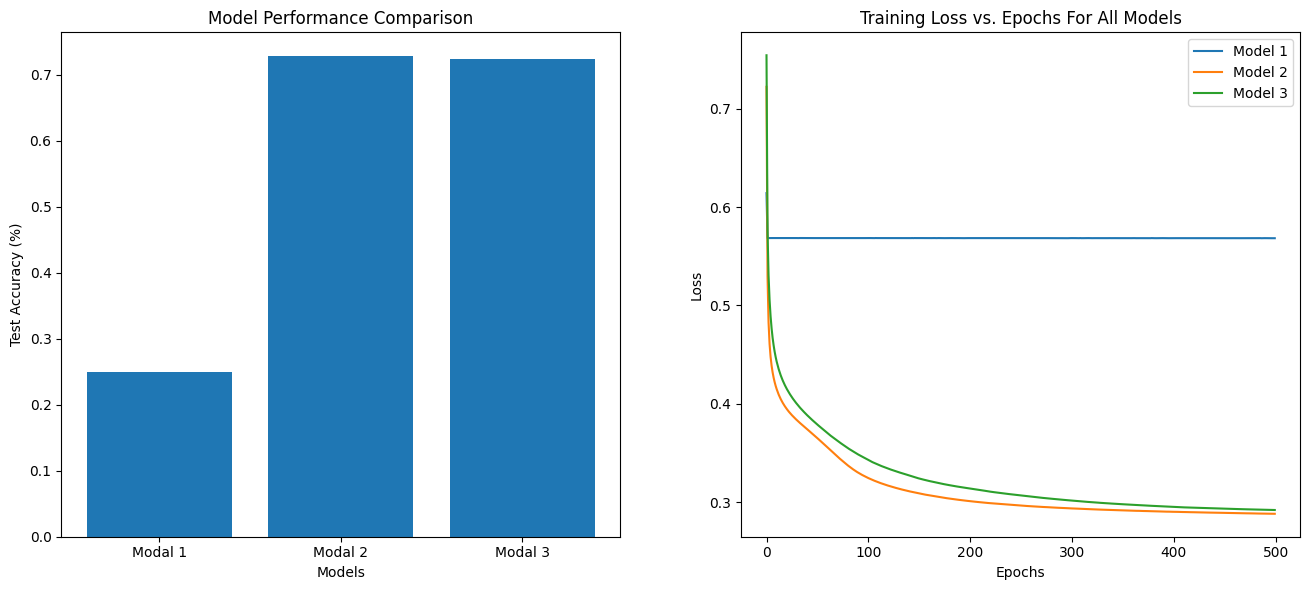

In [12]:
from statsmodels.stats.contingency_tables import mcnemar
import pprint

pp = pprint.PrettyPrinter(indent=2, depth=4)

mcNemar_test_dict = {
	"model1": {
		"model2": {
			"p_value" : None,
			"statistic": None
		},
		"model3": {
			"p_value" : None,
			"statistic": None
		}
	},
	"model2": {
		"model3": {
			"p_value" : None,
			"statistic": None
		}
	}
}

y_test_pred_dict = {
	"model1": y_test_pred_model1,
	"model2": y_test_pred_model2,
	"model3": y_test_pred_model3,
}

for outer_model in mcNemar_test_dict:
	for inner_model in mcNemar_test_dict[outer_model]:
		both_correct = np.sum((y_test_pred_dict[outer_model] == y_test) & (y_test_pred_dict[inner_model] == y_test))
		outer_model_correct = np.sum((y_test_pred_dict[outer_model] == y_test) & (y_test_pred_dict[inner_model] != y_test))
		inner_model_correct = np.sum((y_test_pred_dict[outer_model] != y_test) & (y_test_pred_dict[inner_model] == y_test))
		both_wrong = np.sum((y_test_pred_dict[outer_model] != y_test) & (y_test_pred_dict[inner_model] != y_test))

		contingency_table = [[both_correct, outer_model_correct],
												[inner_model_correct, both_wrong]]

		result = mcnemar(contingency_table, exact=True)
		mcNemar_test_dict[outer_model][inner_model]["p_value"] = result.pvalue
		mcNemar_test_dict[outer_model][inner_model]["statistic"] = result.statistic
								
pp.pprint(mcNemar_test_dict)

model_type = ["Modal 1", "Modal 2", "Modal 3"]
model_test_acc = [test_acc_model1, test_acc_model2, test_acc_model3]


plt.figure(figsize=(20, 6))
plt.subplot(1, 3, 1)
plt.bar(model_type, model_test_acc)
plt.title('Model Performance Comparison')
plt.ylabel('Test Accuracy (%)')
plt.xlabel('Models')

plt.subplot(1, 3, 2)
plt.plot(range(len(two_layer_nn_model1.cost_)), two_layer_nn_model1.cost_, label ="Model 1")
plt.plot(range(len(two_layer_nn_model2.cost_)), two_layer_nn_model2.cost_, label = "Model 2")
plt.plot(range(len(two_layer_nn_model3.cost_)), two_layer_nn_model3.cost_, label = "Model 3")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss vs. Epochs For All Models')
plt.legend()

plt.tight_layout(w_pad=5.0)
plt.show()

#### Model Analysis

<b>Model 1 vs Model 2, Model 3:</b> From the result, we can see that model 1 is completely different from the other 2 mode with a p value of 0, and with a chi square of 1106, and 1165 which are both greater than 3.841. This is because model 1 uses raw data to train the model, while model 2, and 3 uses normalized data. 

<b>Model 2 vs Model 3:</b> The mcnemar test gave us a p value of 0.0672, and chi square of 454 which indicates that the model is different from one another, however from the accuracy test, we can see that the model had the same near identical result. This could indicated that the model makes different prediction error, the over accuracy is almost the same. 

In addition, the loss graph also supports the mcnemar findings. We can see that model flattens out around 0.58 through the training sets, showing that the model was not able to learn anything from the raw data provided. This is due to the raw data having various different values which makes it difficult for the model to be trained on, as the large values in the dataset to affect the gradient, and preventing meaningful updates to the weight. 

Model 2, and model 3 are nearly identical to one another, as both show that the start converging around 200 epochs as well as the loss curve from 0.75 to around 0.30. This indicated that the normalizing the dataset before training is important in getting a better result out of the neural network. As indicated by the accuracy. 

## 3. Modeling

### 3.1 Add 3rd layer

In [13]:
# based on two layer perceptron, added a third layer
# add average magnitude using L2
class ThreeLayerPerceptron:
	def __init__(self, n_hidden1 =30, n_hidden2=15, C=0.0, epochs=500, eta=0.001, # add n_hidden2
				 random_state=None, shuffle=True, minibatches=1):
		np.random.seed(random_state)
		self.n_hidden1 = n_hidden1
		self.n_hidden2 = n_hidden2 # add second hidden layer
		self.l2_C = C
		self.epochs = epochs
		self.eta = eta
		self.shuffle = shuffle
		self.minibatches = minibatches
		
	@staticmethod
	def _encode_labels(y):
		"""Encode labels into one-hot representation"""
		onehot = pd.get_dummies(y).values.T
		return onehot

	def _initialize_weights(self):
		"""Initialize weights Glorot and He normalization."""
		init_bound = 4*np.sqrt(6. / (self.n_hidden1 + self.n_features_))
		W1 = np.random.uniform(-init_bound, init_bound, (self.n_hidden1, self.n_features_))
		
		# add second hidden layer weights
		init_bound = 4*np.sqrt(6. / (self.n_hidden2 + self.n_hidden1))
		W2 = np.random.uniform(-init_bound, init_bound, (self.n_hidden2, self.n_hidden1))

		init_bound = 4*np.sqrt(6 / (self.n_output_ + self.n_hidden2))
		W3 = np.random.uniform(-init_bound, init_bound, (self.n_output_, self.n_hidden2))
		

		b1 = np.zeros((self.n_hidden1, 1))
		b2 = np.zeros((self.n_hidden2, 1)) # add second hidden layer bias
		b3 = np.zeros((self.n_output_, 1)) - 2.0  

		return W1, W2, W3, b1, b2, b3

	@staticmethod
	def _sigmoid(z):
		"""Use scipy.special.expit to avoid overflow"""
		return expit(z)
	
	@staticmethod
	def _L2_reg(lambda_, W1, W2, W3):
		"""Compute L2-regularization cost"""
		return (lambda_ / 2.0) * np.sqrt(np.mean(W1 ** 2) # update, without [:, 1:], because bias terms are saved separately
							 + np.mean(W2 ** 2)  
							 + np.mean(W3 ** 2)) 

	def _cost(self, A3, Y_enc, W1, W2, W3):
		"""Get the cross-entropy objective function value"""
		cost = -np.mean(np.nan_to_num((Y_enc*np.log(A3+1e-7)+(1-Y_enc)*np.log(1-A3+1e-7))))
		L2_term = self._L2_reg(self.l2_C, W1, W2, W3)
		return cost + L2_term

	def _feedforward(self, X, W1, W2, W3, b1, b2, b3):
		"""Compute feedforward step"""
		A1 = X.T
		Z1 = W1 @ A1 + b1
		A2 = self._sigmoid(Z1)
		Z2 = W2 @ A2 + b2
		A3 = self._sigmoid(Z2)
		Z3 = W3 @ A3 + b3
		A4 = self._sigmoid(Z3)
		return A1, Z1, A2, Z2, A3, Z3, A4

	def _get_gradient(self, A1, A2, A3, A4, Z1, Z2, Z3, Y_enc, W1, W2, W3):
		"""Compute gradient step using vectorized backpropagation with cross-entropy loss."""
		V3 = (A4 - Y_enc) # add V3
		V2 = A3 * (1 - A3) * (W3.T @ V3)
		V1 = A2 * (1 - A2) * (W2.T @ V2)
		
		gradW3 = V3 @ A3.T # add gradW3
		gradW2 = V2 @ A2.T
		gradW1 = V1 @ A1.T
		
		gradb3 = np.sum(V3, axis=1).reshape((-1, 1)) # add gradb3
		gradb2 = np.sum(V2, axis=1).reshape((-1, 1))
		gradb1 = np.sum(V1, axis=1).reshape((-1, 1))
		
		# Regularize weights that are not bias terms
		gradW1 += W1 * self.l2_C
		gradW2 += W2 * self.l2_C
		gradW3 += W3 * self.l2_C # add regularization for W3
    

		return gradW1, gradW2, gradW3, gradb1, gradb2, gradb3
	
	def _update_parameters(self, eta, gradW1, gradW2, gradW3, gradb1, gradb2, gradb3):
		"""Update weights using gradient descent"""
		self.W1 -= eta * gradW1
		self.W2 -= eta * gradW2
		self.W3 -= eta * gradW3 # add W3 update
		self.b1 -= eta * gradb1
		self.b2 -= eta * gradb2
		self.b3 -= eta * gradb3 # add b3 update

	def fit(self, X, y, print_progress=False, XY_test=None):
		"""Learn weights from training data with mini-batch"""
		X_data, y_data = X.copy(), y.copy()
		X_data = np.array(X_data)
		y_data = np.array(y_data)
		Y_enc = self._encode_labels(y)
		
		# Init weights and setup matrices
		self.n_features_ = X_data.shape[1]
		self.n_output_ = Y_enc.shape[0]

		if not hasattr(self, 'W1'):
			self.W1, self.W2, self.W3, self.b1, self.b2, self.b3 = self._initialize_weights() # initialize W3, b3

		self.cost_ = []
		self.score_ = []
		self.score_.append(accuracy_score(y_data, self.predict(X_data)))
		self.grad_mags_ = []
		
		# Keep track of validation, if given
		if XY_test is not None:
			X_test = XY_test[0].copy()
			y_test = XY_test[1].copy()
			self.val_score_ = []
			self.val_score_.append(accuracy_score(y_test, self.predict(X_test)))
			
		for i in range(self.epochs):
			if print_progress > 0 and (i + 1) % print_progress == 0:
				sys.stderr.write('\rEpoch: %d/%d' % (i + 1, self.epochs))
				sys.stderr.flush()

			if self.shuffle:
				idx_shuffle = np.random.permutation(y_data.shape[0])
				X_data, Y_enc, y_data = X_data[idx_shuffle], Y_enc[:, idx_shuffle], y_data[idx_shuffle]

			mini = np.array_split(range(y_data.shape[0]), self.minibatches)
			mini_cost = []
			epoch_grad_W1, epoch_grad_W2, epoch_grad_W3 = [], [], [] #add epoch_grad_w3
			
			for idx in mini:
				# Feedforward
				A1, Z1, A2, Z2, A3, Z3, A4 = self._feedforward(X_data[idx], self.W1, 
													   self.W2, self.W3, self.b1, self.b2, self.b3) # add parameters

				cost = self._cost(A4, Y_enc[:, idx], self.W1, self.W2, self.W3) #update cost to include W3
				mini_cost.append(cost)
				
				# Compute gradient via backpropagation, add parameters
				gradW1, gradW2, gradW3, gradb1, gradb2, gradb3 = self._get_gradient(
					A1=A1, A2=A2, A3=A3, A4=A4, Z1=Z1, Z2=Z2, Z3=Z3, 
					Y_enc=Y_enc[:, idx], 
					W1=self.W1, W2=self.W2, W3=self.W3 
				)
				
				# Record gradient magnitudes
				epoch_grad_W1.append(np.linalg.norm(gradW1))
				epoch_grad_W2.append(np.linalg.norm(gradW2))
				epoch_grad_W3.append(np.linalg.norm(gradW3)) # add epoch_grad_w3

				# Update all W and b values
				self._update_parameters(self.eta, gradW1, gradW2, gradW3, gradb1, gradb2, gradb3) #add gradW3, gradb3

			self.cost_.append(np.mean(mini_cost))
			self.score_.append(accuracy_score(y_data, self.predict(X_data)))
			
			self.grad_mags_.append((
				np.mean(epoch_grad_W1),
				np.mean(epoch_grad_W2),
				np.mean(epoch_grad_W3) # add mean for epoch_grad_w3
				))
  
			# Update if a validation set was provided
			if XY_test is not None:
				yhat = self.predict(X_test)
				self.val_score_.append(accuracy_score(y_test, yhat))
			
		return self
	
	def predict(self, X):
		"""Predict class labels"""
		_, _, _, _, _, _, A4 = self._feedforward(X, self.W1, self.W2, self.W3, self.b1, self.b2, self.b3)
		y_pred = np.argmax(A4, axis=0) # update to A4
		return y_pred

Train accuracy: 0.7481177158180631
Test  accuracy: 0.7238036303630363


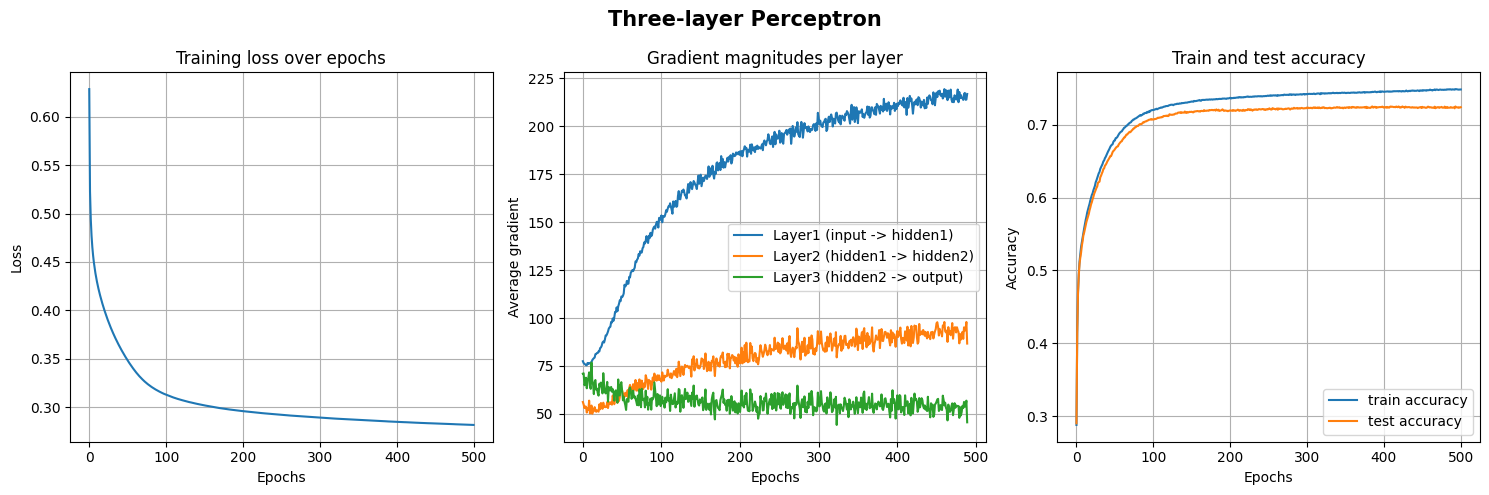

In [14]:
# modeling and visualization - three layer perceptron

# train
nn3_params_dict = {
    'n_hidden1': 40,
    'n_hidden2': 20,
    'C': 0.01,
    'epochs': 500,
    'eta': 0.0001,
    'random_state': 42,
    'shuffle': True,
    'minibatches': 50
}

three_layer_nn = ThreeLayerPerceptron(**nn3_params_dict)

three_layer_nn.fit(X_train_scaled_encoded, y_train, XY_test=(X_test_scaled_encoded, y_test)) # use scaled and encoded data

# quantity performance (accuracy) on train and test
y_pred_train = three_layer_nn.predict(X_train_scaled_encoded)
y_pred_test  = three_layer_nn.predict(X_test_scaled_encoded)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy  = accuracy_score(y_test,  y_pred_test)

print(f"Train accuracy: {train_accuracy}")
print(f"Test  accuracy: {test_accuracy:}")



# plot of loss vs epochs
plt.figure(figsize=(15,5)) # ask GPT to add title correctly
plt.suptitle('Three-layer Perceptron', fontsize=15, fontweight='bold')

plt.subplot(1, 3, 1)
plt.plot(range(len(three_layer_nn.cost_)), three_layer_nn.cost_)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training loss over epochs')
plt.grid(True)

# plot of gradient magnitude (L2 norm) per layer vs epochs
plt.subplot(1, 3, 2)
grad_mags = np.array(three_layer_nn.grad_mags_)
plt.plot(grad_mags[10:, 0], label='Layer1 (input -> hidden1)')
plt.plot(grad_mags[10:, 1], label='Layer2 (hidden1 -> hidden2)')
plt.plot(grad_mags[10:, 2], label='Layer3 (hidden2 -> output)')
plt.xlabel('Epochs')
plt.ylabel('Average gradient')
plt.title('Gradient magnitudes per layer')
plt.legend()
plt.grid(True)

# plot of train vs validation accuracy
plt.subplot(1, 3, 3)
plt.plot(three_layer_nn.score_, label='train accuracy')
if hasattr(three_layer_nn, 'val_score_'):
    plt.plot(three_layer_nn.val_score_, label='test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train and test accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Three-layer perceptron analysis**

According to the training loss plot, the training loss decreases rapidly from 0 to around 200, reaches about 0.29, and gradually becomes stable, indicating the model has learned meaningful results from the data.

According to the gradient magnitudes per layer plot, the Layer 1 (input → hidden1) has the largest gradient magnitudes, and increases over time. But Layer 2 and Layer 3 maintain a low number under 100, with Layer 2 slightly increases and Layer 3 slightly decreases. This pattern aligns with the expected back propagation concepts, reflecting a mild vanishing-gradient effect.

According to the train and test accuracy, both of them increase sharply within the first 200 epochs, and train accuracy is around 0.74, while test accuracy is around 0.72. As epochs grow, the final train accuracy is 0.7481, and the test accuracy is 0.7238. The overall accuracy is not very high, but the small gap between train and test curves indicates that the model has good generalization and limits overfitting.

Compared to two-layer model accuracy(train: 0.7369, test: 0.7242), the train performance increases about 1.5% while the testing accuracy were neatly identical, indicating that the three layer model does not have a significant difference with the two layer model. 

### 3.2 Add 4th layer

In [15]:
# based on three layer perceptron, added a fourth layer

class FourLayerPerceptron:
	def __init__(self, n_hidden1 =50, n_hidden2=30, n_hidden3=15, # add n_hidden3
			  C=0.0, epochs=500, eta=0.001, 
				 random_state=None, shuffle=True, minibatches=1):
		np.random.seed(random_state)
		self.n_hidden1 = n_hidden1
		self.n_hidden2 = n_hidden2
		self.n_hidden3 = n_hidden3 # add third hidden layer
		self.l2_C = C
		self.epochs = epochs
		self.eta = eta
		self.shuffle = shuffle
		self.minibatches = minibatches
		
	@staticmethod
	def _encode_labels(y):
		"""Encode labels into one-hot representation"""
		onehot = pd.get_dummies(y).values.T
		return onehot

	def _initialize_weights(self):
		"""Initialize weights Glorot and He normalization."""
		init_bound = 4*np.sqrt(6. / (self.n_hidden1 + self.n_features_))
		W1 = np.random.uniform(-init_bound, init_bound, (self.n_hidden1, self.n_features_))
		
		init_bound = 4*np.sqrt(6. / (self.n_hidden2 + self.n_hidden1))
		W2 = np.random.uniform(-init_bound, init_bound, (self.n_hidden2, self.n_hidden1))

		init_bound = 4*np.sqrt(6. / (self.n_hidden3 + self.n_hidden2))
		W3 = np.random.uniform(-init_bound, init_bound, (self.n_hidden3, self.n_hidden2))

		# add fourth layer weights
		init_bound = 4*np.sqrt(6. / (self.n_output_ + self.n_hidden3))
		W4 = np.random.uniform(-init_bound, init_bound, (self.n_output_, self.n_hidden3))
		

		b1 = np.zeros((self.n_hidden1, 1))
		b2 = np.zeros((self.n_hidden2, 1)) 
		b3 = np.zeros((self.n_hidden3, 1))
		b4 = np.zeros((self.n_output_, 1)) - 2.0 # add b4

		return W1, W2, W3, W4, b1, b2, b3, b4

	@staticmethod
	def _sigmoid(z):
		"""Use scipy.special.expit to avoid overflow"""
		return expit(z)
	
	@staticmethod
	def _L2_reg(lambda_, W1, W2, W3, W4):
		"""Compute L2-regularization cost"""
		return (lambda_ / 2.0) * np.sqrt(np.mean(W1 ** 2)
							 + np.mean(W2 ** 2)
							 + np.mean(W3 ** 2)
							 + np.mean(W4 ** 2)) # add W4

	def _cost(self, A5, Y_enc, W1, W2, W3, W4):
		"""Get the cross-entropy objective function value"""
		cost = -np.mean(np.nan_to_num((Y_enc*np.log(A5+1e-7)+(1-Y_enc)*np.log(1-A5+1e-7))))
		L2_term = self._L2_reg(self.l2_C, W1, W2, W3, W4) # add W4
		return cost + L2_term

	def _feedforward(self, X, W1, W2, W3, W4, b1, b2, b3, b4):
		"""Compute feedforward step"""
		A1 = X.T
		Z1 = W1 @ A1 + b1
		A2 = self._sigmoid(Z1)
		Z2 = W2 @ A2 + b2
		A3 = self._sigmoid(Z2)
		Z3 = W3 @ A3 + b3
		A4 = self._sigmoid(Z3)
		Z4 = W4 @ A4 + b4 # add Z4
		A5 = self._sigmoid(Z4) # add A5
		return A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5

	def _get_gradient(self, A1, A2, A3, A4, A5, Z1, Z2, Z3, Z4, Y_enc, W1, W2, W3, W4):
		"""Compute gradient step using vectorized backpropagation with cross-entropy loss."""
		# Vectorized backpropagation for cross-entropy
		V4 = (A5 - Y_enc) # add V4
		V3 = A4 * (1 - A4) * (W4.T @ V4) #change v3
		V2 = A3 * (1 - A3) * (W3.T @ V3)
		V1 = A2 * (1 - A2) * (W2.T @ V2)
		
		gradW4 = V4 @ A4.T
		gradW3 = V3 @ A3.T
		gradW2 = V2 @ A2.T
		gradW1 = V1 @ A1.T
		
		gradb4 = np.sum(V4, axis=1).reshape((-1, 1)) # add gradb4
		gradb3 = np.sum(V3, axis=1).reshape((-1, 1))
		gradb2 = np.sum(V2, axis=1).reshape((-1, 1))
		gradb1 = np.sum(V1, axis=1).reshape((-1, 1))
		
		# Regularize weights that are not bias terms
		gradW1 += W1 * self.l2_C
		gradW2 += W2 * self.l2_C
		gradW3 += W3 * self.l2_C
		gradW4 += W4 * self.l2_C # add W4
		

		return gradW1, gradW2, gradW3, gradW4, gradb1, gradb2, gradb3, gradb4
	
	def _update_parameters(self, eta, gradW1, gradW2, gradW3, gradW4, gradb1, gradb2, gradb3, gradb4):
		"""Update weights using gradient descent"""
		self.W1 -= eta * gradW1
		self.W2 -= eta * gradW2
		self.W3 -= eta * gradW3
		self.W4 -= eta * gradW4 # add W4
		self.b1 -= eta * gradb1
		self.b2 -= eta * gradb2
		self.b3 -= eta * gradb3
		self.b4 -= eta * gradb4 # add b4

	def fit(self, X, y, print_progress=False, XY_test=None):
		"""Learn weights from training data with mini-batch"""
		X_data, y_data = X.copy(), y.copy()
		X_data = np.array(X_data)
		y_data = np.array(y_data)
		Y_enc = self._encode_labels(y)
		
		# Init weights and setup matrices
		self.n_features_ = X_data.shape[1]
		self.n_output_ = Y_enc.shape[0]

		if not hasattr(self, 'W1'):
			(self.W1, self.W2, self.W3, self.W4,
			self.b1, self.b2, self.b3, self.b4) = self._initialize_weights()

		self.cost_ = []
		self.score_ = []
		self.score_.append(accuracy_score(y_data, self.predict(X_data)))
		self.grad_mags_ = []
		
		# Keep track of validation, if given
		if XY_test is not None:
			X_test = XY_test[0].copy()
			y_test = XY_test[1].copy()
			self.val_score_ = []
			self.val_score_.append(accuracy_score(y_test, self.predict(X_test)))
			
		for i in range(self.epochs):
			if print_progress > 0 and (i + 1) % print_progress == 0:
				sys.stderr.write('\rEpoch: %d/%d' % (i + 1, self.epochs))
				sys.stderr.flush()

			if self.shuffle:
				idx_shuffle = np.random.permutation(y_data.shape[0])
				X_data, Y_enc, y_data = X_data[idx_shuffle], Y_enc[:, idx_shuffle], y_data[idx_shuffle]

			mini = np.array_split(range(y_data.shape[0]), self.minibatches)
			mini_cost = []
			epoch_grad_W1, epoch_grad_W2, epoch_grad_W3, epoch_grad_W4 = [], [], [], [] #add epoch_grad_w4
			
			for idx in mini:
				# Feedforward
				A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5 = self._feedforward(X_data[idx], self.W1,
													   self.W2, self.W3, self.W4, self.b1, self.b2, self.b3, self.b4)

				cost = self._cost(A5, Y_enc[:, idx], self.W1, self.W2, self.W3, self.W4)
				mini_cost.append(cost)
				
				# Compute gradient via backpropagation
				gradW1, gradW2, gradW3, gradW4, gradb1, gradb2, gradb3, gradb4 = self._get_gradient(
					A1=A1, A2=A2, A3=A3, A4=A4, A5=A5, 
					Z1=Z1, Z2=Z2, Z3=Z3, Z4=Z4,
					Y_enc=Y_enc[:, idx], 
					W1=self.W1, W2=self.W2, W3=self.W3, W4=self.W4 # update with W4
				)
				
				# Record gradient magnitudes
				epoch_grad_W1.append(np.linalg.norm(gradW1))
				epoch_grad_W2.append(np.linalg.norm(gradW2))
				epoch_grad_W3.append(np.linalg.norm(gradW3))
				epoch_grad_W4.append(np.linalg.norm(gradW4)) # add epoch_grad_w4

				# Update all W and b values
				self._update_parameters(self.eta, gradW1, gradW2, gradW3, gradW4, gradb1, gradb2, gradb3, gradb4)

			self.cost_.append(np.mean(mini_cost))
			self.score_.append(accuracy_score(y_data, self.predict(X_data)))
			
			self.grad_mags_.append((
				np.mean(epoch_grad_W1),
				np.mean(epoch_grad_W2),
				np.mean(epoch_grad_W3),
				np.mean(epoch_grad_W4))) # add mean for epoch_grad_w4
			
			# Update if a validation set was provided
			if XY_test is not None:
				yhat = self.predict(X_test)
				self.val_score_.append(accuracy_score(y_test, yhat))
			
		return self
	
	def predict(self, X):
		"""Predict class labels"""
		_, _, _, _, _, _, _, _, A5 = self._feedforward(X, self.W1, self.W2, self.W3, self.W4, 
												 self.b1, self.b2, self.b3, self.b4) # add parameters
		y_pred = np.argmax(A5, axis=0)
		return y_pred

Train accuracy: 0.753326228211916
Test  accuracy: 0.7223597359735974


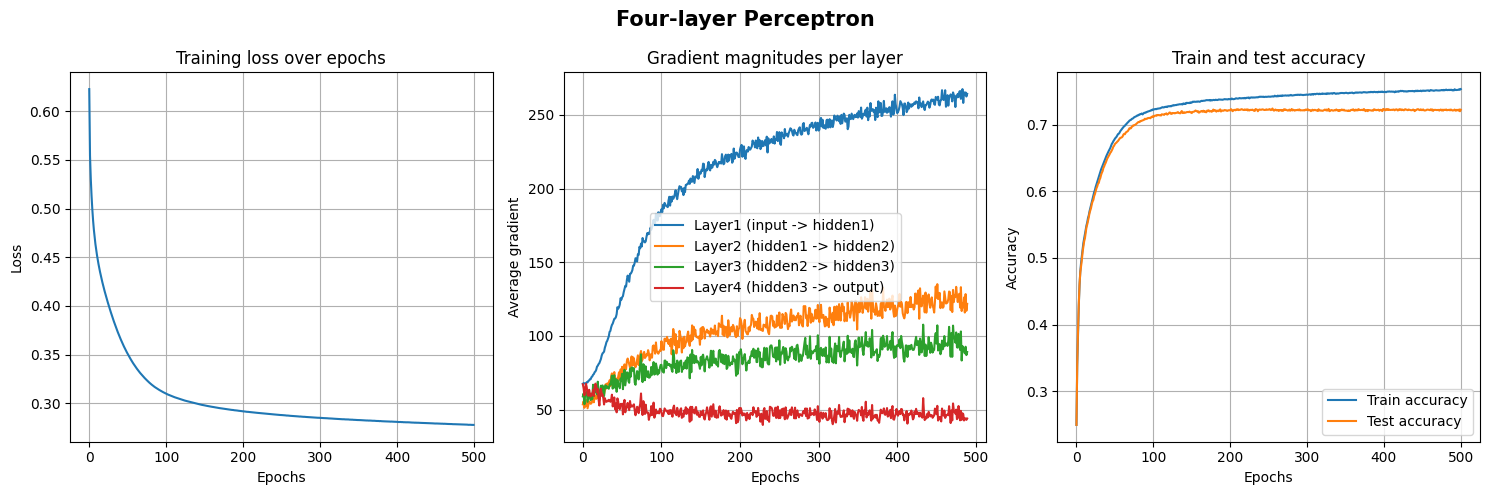

In [16]:
# modeling and visualization - four layer perceptron

# train
nn4_params_dict = {
    'n_hidden1': 50,
    'n_hidden2': 30,
    'n_hidden3': 15,
    'C': 0.01,
    'epochs': 500,
    'eta': 0.0001,
    'random_state': 42,
    'shuffle': True,
    'minibatches': 50
}

four_layer_nn = FourLayerPerceptron(**nn4_params_dict)

four_layer_nn.fit(X_train_scaled_encoded, y_train, XY_test=(X_test_scaled_encoded, y_test))

# quantity performance (accuracy) on train and test
y_pred_train = four_layer_nn.predict(X_train_scaled_encoded)
y_pred_test  = four_layer_nn.predict(X_test_scaled_encoded)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test,  y_pred_test)

# quantity performance (accuracy) on train and test


print(f"Train accuracy: {train_accuracy}")
print(f"Test  accuracy: {test_accuracy}")


# plot of loss vs epochs
plt.figure(figsize=(15,5))
plt.suptitle('Four-layer Perceptron', fontsize=15, fontweight='bold')

plt.subplot(1, 3, 1)
plt.plot(range(len(four_layer_nn.cost_)), four_layer_nn.cost_)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training loss over epochs')
plt.grid(True)

# plot of gradient magnitude (L2 norm) per layer vs epochs
plt.subplot(1, 3, 2)
grad_mags = np.array(four_layer_nn.grad_mags_)
plt.plot(grad_mags[10:, 0], label='Layer1 (input -> hidden1)')
plt.plot(grad_mags[10:, 1], label='Layer2 (hidden1 -> hidden2)')
plt.plot(grad_mags[10:, 2], label='Layer3 (hidden2 -> hidden3)')
plt.plot(grad_mags[10:, 3], label='Layer4 (hidden3 -> output)')
plt.xlabel('Epochs')
plt.ylabel('Average gradient')
plt.title('Gradient magnitudes per layer')
plt.legend()
plt.grid(True)

# plot of train vs validation accuracy
plt.subplot(1, 3, 3)
plt.plot(four_layer_nn.score_, label='Train accuracy')
if hasattr(four_layer_nn, 'val_score_'):
    plt.plot(four_layer_nn.val_score_, label='Test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train and test accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Four-layer perceptron analysis**

The result of the four-layer perceptron is similar to the three-layer perceptron. 

The training loss plot shows the similar pattern that the loss decrease slower from around 200, and reaches 0.29.

The gradient magnitudes show the similar patterns as well, and the input layer (Layer1) increases, the output layer (Layer2) decreases slightly, and the inner layers (Layer2 and Layer3) increase slightly. However, the gap between Layer1 and Layer 4 are wider, because Layer 1 reaches abour 275, and Layer 4 reaches about 45.

The train and test accuracy also follow the same pattern, with a little bit fast-growth from 0 to 100, and becomes stable from 200 epochs, and the final train accuracy is 0.7533, and the test accuracy is 0.7224.

Compared to the three-layer model accuracy(Train: 0.7481, Test: 0.7238), the test accuracy only improves 0.08%, indicating that four-layer doesn't have significant improvement on accuracy performance.

### 3.3 5th layer

In [17]:
# based on 4-layer perceptron, added a fifth layer

class FiveLayerPerceptron:
	def __init__(self, n_hidden1 =50, n_hidden2=30, n_hidden3=15, n_hidden4=8,  # add n_hidden4
			  C=0.0, epochs=500, eta=0.001, random_state=None, shuffle=True, minibatches=1):
		np.random.seed(random_state)
		self.n_hidden1 = n_hidden1
		self.n_hidden2 = n_hidden2
		self.n_hidden3 = n_hidden3
		self.n_hidden4 = n_hidden4  # add fourth hidden layer
		self.l2_C = C
		self.epochs = epochs
		self.eta = eta
		self.shuffle = shuffle
		self.minibatches = minibatches
		
	@staticmethod
	def _encode_labels(y):
		"""Encode labels into one-hot representation"""
		onehot = pd.get_dummies(y).values.T
		return onehot

	def _initialize_weights(self):
		"""Initialize weights Glorot and He normalization."""
		init_bound = 4*np.sqrt(6. / (self.n_hidden1 + self.n_features_))
		W1 = np.random.uniform(-init_bound, init_bound, (self.n_hidden1, self.n_features_))
		
		init_bound = 4*np.sqrt(6. / (self.n_hidden2 + self.n_hidden1))
		W2 = np.random.uniform(-init_bound, init_bound, (self.n_hidden2, self.n_hidden1))

		init_bound = 4*np.sqrt(6. / (self.n_hidden3 + self.n_hidden2))
		W3 = np.random.uniform(-init_bound, init_bound, (self.n_hidden3, self.n_hidden2))

		init_bound = 4*np.sqrt(6. / (self.n_hidden4 + self.n_hidden3))
		W4 = np.random.uniform(-init_bound, init_bound, (self.n_hidden4, self.n_hidden3))
		
        # add fifth layer weights
		init_bound = 4*np.sqrt(6. / (self.n_output_ + self.n_hidden4))
		W5 = np.random.uniform(-init_bound, init_bound, (self.n_output_, self.n_hidden4))

		b1 = np.zeros((self.n_hidden1, 1))
		b2 = np.zeros((self.n_hidden2, 1)) 
		b3 = np.zeros((self.n_hidden3, 1))
		b4 = np.zeros((self.n_hidden4, 1))
		b5 = np.zeros((self.n_output_, 1)) - 2.0 # add b5

		return W1, W2, W3, W4, W5, b1, b2, b3, b4, b5

	@staticmethod
	def _sigmoid(z):
		"""Use scipy.special.expit to avoid overflow"""
		return expit(z)
	
	@staticmethod
	def _L2_reg(lambda_, W1, W2, W3, W4, W5):
		"""Compute L2-regularization cost"""
		return (lambda_ / 2.0) * np.sqrt(np.mean(W1 ** 2)
							 + np.mean(W2 ** 2)
							 + np.mean(W3 ** 2)
							 + np.mean(W4 ** 2)
							 + np.mean(W5 ** 2)) # add W5

	def _cost(self, A6, Y_enc, W1, W2, W3, W4, W5):
		"""Get the cross-entropy objective function value"""
		cost = -np.mean(np.nan_to_num((Y_enc*np.log(A6+1e-7)+(1-Y_enc)*np.log(1-A6+1e-7))))
		L2_term = self._L2_reg(self.l2_C, W1, W2, W3, W4, W5) # add W5
		return cost + L2_term

	def _feedforward(self, X, W1, W2, W3, W4, W5, b1, b2, b3, b4, b5):
		"""Compute feedforward step"""
		A1 = X.T
		Z1 = W1 @ A1 + b1
		A2 = self._sigmoid(Z1)
		Z2 = W2 @ A2 + b2
		A3 = self._sigmoid(Z2)
		Z3 = W3 @ A3 + b3
		A4 = self._sigmoid(Z3)
		Z4 = W4 @ A4 + b4
		A5 = self._sigmoid(Z4)
		Z5 = W5 @ A5 + b5 # add Z5
		A6 = self._sigmoid(Z5) # add A6
		return A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5, Z5, A6

	def _get_gradient(self, A1, A2, A3, A4, A5, A6, Z1, Z2, Z3, Z4, Z5, Y_enc, W1, W2, W3, W4, W5):
		"""Compute gradient step using vectorized backpropagation with cross-entropy loss."""
		# Vectorized backpropagation for cross-entropy
		V5 = (A6 - Y_enc) # add V5
		V4 = A5 * (1 - A5) * (W5.T @ V5) # change v4
		V3 = A4 * (1 - A4) * (W4.T @ V4)
		V2 = A3 * (1 - A3) * (W3.T @ V3)
		V1 = A2 * (1 - A2) * (W2.T @ V2)
		
		gradW5 = V5 @ A5.T  # add gradW5
		gradW4 = V4 @ A4.T
		gradW3 = V3 @ A3.T
		gradW2 = V2 @ A2.T
		gradW1 = V1 @ A1.T
		
		gradb5 = np.sum(V5, axis=1).reshape((-1, 1))  # add gradb5
		gradb4 = np.sum(V4, axis=1).reshape((-1, 1))
		gradb3 = np.sum(V3, axis=1).reshape((-1, 1))
		gradb2 = np.sum(V2, axis=1).reshape((-1, 1))
		gradb1 = np.sum(V1, axis=1).reshape((-1, 1))
		
		# Regularize weights that are not bias terms
		gradW1 += W1 * self.l2_C
		gradW2 += W2 * self.l2_C
		gradW3 += W3 * self.l2_C
		gradW4 += W4 * self.l2_C
		gradW5 += W5 * self.l2_C # add W5
		

		return gradW1, gradW2, gradW3, gradW4, gradW5, gradb1, gradb2, gradb3, gradb4, gradb5

	def _update_parameters(self, eta, gradW1, gradW2, gradW3, gradW4, gradW5, gradb1, gradb2, gradb3, gradb4, gradb5):
		"""Update weights using gradient descent"""
		self.W1 -= eta * gradW1
		self.W2 -= eta * gradW2
		self.W3 -= eta * gradW3
		self.W4 -= eta * gradW4
		self.W5 -= eta * gradW5 # add W5
		self.b1 -= eta * gradb1
		self.b2 -= eta * gradb2
		self.b3 -= eta * gradb3
		self.b4 -= eta * gradb4
		self.b5 -= eta * gradb5 # add b5

	def fit(self, X, y, print_progress=False, XY_test=None):
		"""Learn weights from training data with mini-batch"""
		X_data, y_data = X.copy(), y.copy()
		X_data = np.array(X_data)
		y_data = np.array(y_data)
		Y_enc = self._encode_labels(y)
		
		# Init weights and setup matrices
		self.n_features_ = X_data.shape[1]
		self.n_output_ = Y_enc.shape[0]

		if not hasattr(self, 'W1'):
			(self.W1, self.W2, self.W3, self.W4, self.W5,
			self.b1, self.b2, self.b3, self.b4, self.b5) = self._initialize_weights()

		self.cost_ = []
		self.score_ = []
		self.score_.append(accuracy_score(y_data, self.predict(X_data)))
		self.grad_mags_ = []
		
		# Keep track of validation, if given
		if XY_test is not None:
			X_test = XY_test[0].copy()
			y_test = XY_test[1].copy()
			self.val_score_ = []
			self.val_score_.append(accuracy_score(y_test, self.predict(X_test)))
			
		for i in range(self.epochs):
			if print_progress > 0 and (i + 1) % print_progress == 0:
				sys.stderr.write('\rEpoch: %d/%d' % (i + 1, self.epochs))
				sys.stderr.flush()

			if self.shuffle:
				idx_shuffle = np.random.permutation(y_data.shape[0])
				X_data, Y_enc, y_data = X_data[idx_shuffle], Y_enc[:, idx_shuffle], y_data[idx_shuffle]

			mini = np.array_split(range(y_data.shape[0]), self.minibatches)
			mini_cost = []
			epoch_grad_W1, epoch_grad_W2, epoch_grad_W3, epoch_grad_W4, epoch_grad_W5 = [], [], [], [], []
			
			for idx in mini:
				# Feedforward
				A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5, Z5, A6 = self._feedforward(X_data[idx], self.W1,
													   self.W2, self.W3, self.W4, self.W5, self.b1, self.b2, self.b3, self.b4, self.b5)

				cost = self._cost(A6, Y_enc[:, idx], self.W1, self.W2, self.W3, self.W4, self.W5)
				mini_cost.append(cost)
				
				# Compute gradient via backpropagation
				gradW1, gradW2, gradW3, gradW4, gradW5, gradb1, gradb2, gradb3, gradb4, gradb5 = self._get_gradient(
					A1=A1, A2=A2, A3=A3, A4=A4, A5=A5, A6=A6,
					Z1=Z1, Z2=Z2, Z3=Z3, Z4=Z4, Z5=Z5,
					Y_enc=Y_enc[:, idx], 
					W1=self.W1, W2=self.W2, W3=self.W3, W4=self.W4, W5=self.W5
				)
				
                # Record gradient magnitudes
				epoch_grad_W1.append(np.linalg.norm(gradW1))
				epoch_grad_W2.append(np.linalg.norm(gradW2))
				epoch_grad_W3.append(np.linalg.norm(gradW3))
				epoch_grad_W4.append(np.linalg.norm(gradW4))
				epoch_grad_W5.append(np.linalg.norm(gradW5))

				# Update all W and b values
				self._update_parameters(self.eta, gradW1, gradW2, gradW3, gradW4, gradW5, gradb1, gradb2, gradb3, gradb4, gradb5)

			self.cost_.append(np.mean(mini_cost))
			self.score_.append(accuracy_score(y_data, self.predict(X_data)))
			
			self.grad_mags_.append((
				np.mean(epoch_grad_W1),
				np.mean(epoch_grad_W2),
				np.mean(epoch_grad_W3),
				np.mean(epoch_grad_W4),
				np.mean(epoch_grad_W5)))
  
			# Update if a validation set was provided
			if XY_test is not None:
				yhat = self.predict(X_test)
				self.val_score_.append(accuracy_score(y_test, yhat))
			
		return self
	
	def predict(self, X):
		"""Predict class labels"""
		_, _, _, _, _, _, _, _, _, _, A6 = self._feedforward(X, self.W1, self.W2, self.W3, self.W4, self.W5,
												 self.b1, self.b2, self.b3, self.b4, self.b5)
		y_pred = np.argmax(A6, axis=0)
		return y_pred

Train accuracy: 0.7520
Test  accuracy: 0.7224


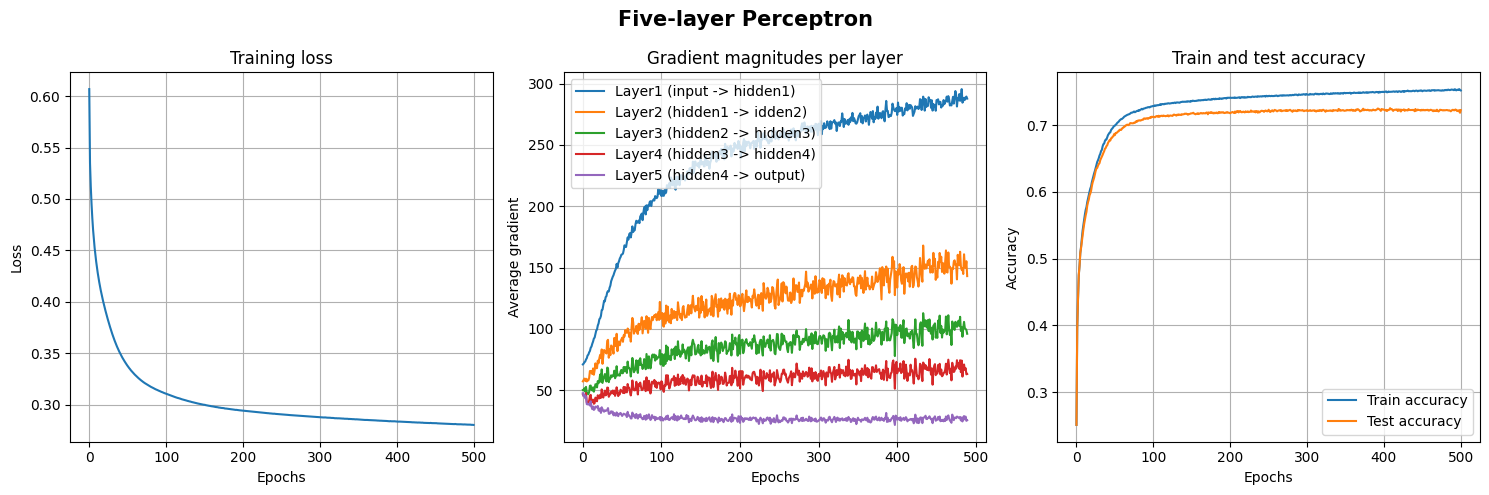

In [18]:
# modeling and visualization - five layer perceptron

# train
nn5_params_dict = {
    'n_hidden1': 50,
    'n_hidden2': 30,
    'n_hidden3': 15,
    'n_hidden4': 8,
    'C': 0.01,
    'epochs': 500,
    'eta': 0.0001,
    'random_state': 42,
    'shuffle': True,
    'minibatches': 50
}

five_layer_nn = FiveLayerPerceptron(**nn5_params_dict)

five_layer_nn.fit(X_train_scaled_encoded, y_train, XY_test=(X_test_scaled_encoded, y_test))

# quantity performance (accuracy) on train and test
y_pred_train = five_layer_nn.predict(X_train_scaled_encoded)
y_pred_test  = five_layer_nn.predict(X_test_scaled_encoded)


train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)

print(f"Train accuracy: {train_acc:.4f}")
print(f"Test  accuracy: {test_acc:.4f}")

# plot of loss vs epochs
plt.figure(figsize=(15,5))
plt.suptitle('Five-layer Perceptron', fontsize=15, fontweight='bold')

plt.subplot(1, 3, 1)
plt.plot(range(len(five_layer_nn.cost_)), five_layer_nn.cost_)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training loss')
plt.grid(True)

# plot of gradient magnitude (L2 norm) per layer vs epochs
plt.subplot(1, 3, 2)
grad_mags = np.array(five_layer_nn.grad_mags_)
plt.plot(grad_mags[10:, 0], label='Layer1 (input -> hidden1)')
plt.plot(grad_mags[10:, 1], label='Layer2 (hidden1 -> idden2)')
plt.plot(grad_mags[10:, 2], label='Layer3 (hidden2 -> hidden3)')
plt.plot(grad_mags[10:, 3], label='Layer4 (hidden3 -> hidden4)')
plt.plot(grad_mags[10:, 4], label='Layer5 (hidden4 -> output)')
plt.xlabel('Epochs')
plt.ylabel('Average gradient')
plt.title('Gradient magnitudes per layer')
plt.legend()
plt.grid(True)

# plot of train vs validation accuracy
plt.subplot(1, 3, 3)
plt.plot(five_layer_nn.score_, label='Train accuracy')
if hasattr(five_layer_nn, 'val_score_'):
    plt.plot(five_layer_nn.val_score_, label='Test accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Train and test accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

**Five-layer perceptron analysis**

The result of the five-layer perceptron is similar to the four-layer perceptron and the three-layer perceptron. 

The training loss plot has the similar pattern that the loss decrease slower from around 200, and reaches 0.29.

The gradient magnitudes shows the similar pattern too, and the input layer (Layer1) increases, the output layer (Layer2) decreases slightly, and the inner layers (Layer2, Layer3, Layer 4) increase slightly. The average gradient values are little bit different, the gap between Layer 1 and Layer 2 is wider then previous models, Layer 1 reaches about 290, and the Layer 5 reaches about 25.

The train and test accuracy are also super close to the previous model, but grows faster in the first 100 epochs, becomes stable from about 150 epochs, and the final train accuracy is 0.7520, and the test accuracy is 0.7224.

Compared to the four-layer model accuracy(Train: 0.7533, Test: 0.7224), the test remains to be the same, indicating that five-layer doesn't have significant improvement on accuracy performance.

### 3.4 Five-layer Perceptron with RMSProp

**Discuss the adaptive method**

We choose RMSProp as the adaptive method, because compared with AdaDelta RMSProp is more straightforward and doesn't require storing many past updates. Also, RMSProp fits well into our plain version five-layer perceptron, the main thing that needs to be updated is the learning rate, which uses the moving average of squared gradients. So, using RMSProp will make the training more stable and speed up convergence.



In [19]:
# based on 5-layer perceptron, added RMSProp 

class FiveLayerPerceptronRMSProp(FiveLayerPerceptron):
	def __init__(self, n_hidden1 =50, n_hidden2=30, n_hidden3=15, n_hidden4=8,
			    C=0.0, epochs=500, eta=0.001,
				 random_state=None, shuffle=True, minibatches=1,
				 rms_rho=0.9, rms_eps=1e-7): # add rms_rho, use 0.9 to keep more history, rms_eps to avoid div by zero
		# Call parent constructor instead of writing all parameters
		super().__init__(n_hidden1, n_hidden2, n_hidden3, n_hidden4,
				 C, epochs, eta, random_state, shuffle, minibatches)
		self.rms_rho = rms_rho  # decay rate
		self.rms_eps = rms_eps  # smoothing term

	# RMSProp parameters initialization
	def _init_rms_params(self):
		self.rms_W1 = np.zeros_like(self.W1)
		self.rms_W2 = np.zeros_like(self.W2)
		self.rms_W3 = np.zeros_like(self.W3)
		self.rms_W4 = np.zeros_like(self.W4)
		self.rms_W5 = np.zeros_like(self.W5)
		self.rms_b1 = np.zeros_like(self.b1)
		self.rms_b2 = np.zeros_like(self.b2)
		self.rms_b3 = np.zeros_like(self.b3)
		self.rms_b4 = np.zeros_like(self.b4)
		self.rms_b5 = np.zeros_like(self.b5)

	# update RMSProp parameters
	def _update_rms_params(self, gradW1, gradW2, gradW3, gradW4, gradW5,
							   gradb1, gradb2, gradb3, gradb4, gradb5):
		
		# calculate moving average of squared gradients for weights and biases
		self.rms_W1 = self.rms_rho * self.rms_W1 + (1.0 - self.rms_rho) * (gradW1 ** 2)
		self.rms_W2 = self.rms_rho * self.rms_W2 + (1.0 - self.rms_rho) * (gradW2 ** 2)
		self.rms_W3 = self.rms_rho * self.rms_W3 + (1.0 - self.rms_rho) * (gradW3 ** 2)
		self.rms_W4 = self.rms_rho * self.rms_W4 + (1.0 - self.rms_rho) * (gradW4 ** 2)
		self.rms_W5 = self.rms_rho * self.rms_W5 + (1.0 - self.rms_rho) * (gradW5 ** 2)

		self.rms_b1 = self.rms_rho * self.rms_b1 + (1.0 - self.rms_rho) * (gradb1 ** 2)
		self.rms_b2 = self.rms_rho * self.rms_b2 + (1.0 - self.rms_rho) * (gradb2 ** 2)
		self.rms_b3 = self.rms_rho * self.rms_b3 + (1.0 - self.rms_rho) * (gradb3 ** 2)
		self.rms_b4 = self.rms_rho * self.rms_b4 + (1.0 - self.rms_rho) * (gradb4 ** 2)
		self.rms_b5 = self.rms_rho * self.rms_b5 + (1.0 - self.rms_rho) * (gradb5 ** 2)

		# update weights and biases using RMSProp formula
		self.W1 -= self.eta * gradW1 / (np.sqrt(self.rms_W1) + self.rms_eps)
		self.W2 -= self.eta * gradW2 / (np.sqrt(self.rms_W2) + self.rms_eps)
		self.W3 -= self.eta * gradW3 / (np.sqrt(self.rms_W3) + self.rms_eps)
		self.W4 -= self.eta * gradW4 / (np.sqrt(self.rms_W4) + self.rms_eps)
		self.W5 -= self.eta * gradW5 / (np.sqrt(self.rms_W5) + self.rms_eps)

		self.b1 -= self.eta * gradb1 / (np.sqrt(self.rms_b1) + self.rms_eps)
		self.b2 -= self.eta * gradb2 / (np.sqrt(self.rms_b2) + self.rms_eps)
		self.b3 -= self.eta * gradb3 / (np.sqrt(self.rms_b3) + self.rms_eps)
		self.b4 -= self.eta * gradb4 / (np.sqrt(self.rms_b4) + self.rms_eps)
		self.b5 -= self.eta * gradb5 / (np.sqrt(self.rms_b5) + self.rms_eps)


	# fit with RMSProp
	def fit(self, X, y, print_progress=False, XY_test=None):
		X_data, y_data = np.array(X), np.array(y)
		Y_enc = self._encode_labels(y)

		# Initialize weights and setup matrices
		self.n_features_ = X_data.shape[1]
		self.n_output_   = Y_enc.shape[0]

		if not hasattr(self, 'W1'):
			(self.W1, self.W2, self.W3, self.W4, self.W5,
				self.b1, self.b2, self.b3, self.b4, self.b5) = self._initialize_weights()

		# Initialize RMSProp parameters
		self._init_rms_params()

		self.cost_, self.score_, self.grad_mags_ = [], [], []
		self.score_.append(accuracy_score(y_data, self.predict(X_data)))

		if XY_test is not None:
			X_test, y_test = XY_test
			self.val_score_ = [accuracy_score(y_test, self.predict(X_test))]

		for i in range(self.epochs):
			if print_progress and (i + 1) % print_progress == 0:
				sys.stderr.write(f'\rEpoch: {i+1}/{self.epochs}')
				sys.stderr.flush()

			if self.shuffle:
				idx = np.random.permutation(y_data.shape[0])
				X_data, Y_enc, y_data = X_data[idx], Y_enc[:, idx], y_data[idx]

			mini = np.array_split(range(y_data.shape[0]), self.minibatches)
			mini_cost = []
			eW1, eW2, eW3, eW4, eW5 = [], [], [], [], []

			for idx in mini:
				A1,Z1,A2,Z2,A3,Z3,A4,Z4,A5,Z5,A6 = self._feedforward(
					X_data[idx], self.W1, self.W2, self.W3, self.W4, self.W5,
					self.b1, self.b2, self.b3, self.b4, self.b5
				)

				cost = self._cost(A6, Y_enc[:, idx], self.W1, self.W2, self.W3, self.W4, self.W5)
				mini_cost.append(cost)

				(gW1,gW2,gW3,gW4,gW5,
					gb1,gb2,gb3,gb4,gb5) = self._get_gradient(
					A1,A2,A3,A4,A5,A6, Z1,Z2,Z3,Z4,Z5, Y_enc[:, idx],
					self.W1,self.W2,self.W3,self.W4,self.W5
				)

				eW1.append(np.linalg.norm(gW1))
				eW2.append(np.linalg.norm(gW2))
				eW3.append(np.linalg.norm(gW3))
				eW4.append(np.linalg.norm(gW4))
				eW5.append(np.linalg.norm(gW5))

				# replaces self._update_parameters
				self._update_rms_params(gW1,gW2,gW3,gW4,gW5, gb1,gb2,gb3,gb4,gb5)


			self.cost_.append(np.mean(mini_cost))
			self.score_.append(accuracy_score(y_data, self.predict(X_data)))
			self.grad_mags_.append((np.mean(eW1), np.mean(eW2), np.mean(eW3), np.mean(eW4), np.mean(eW5)))

			if XY_test is not None:
				self.val_score_.append(accuracy_score(y_test, self.predict(X_test)))

		return self

Plain:   Train Accuracy = 0.7412, Test Accuracy = 0.7178, Time = 143.21s
RMSProp: Train Accuracy = 0.7220, Test Accuracy = 0.7074, Time = 141.87s


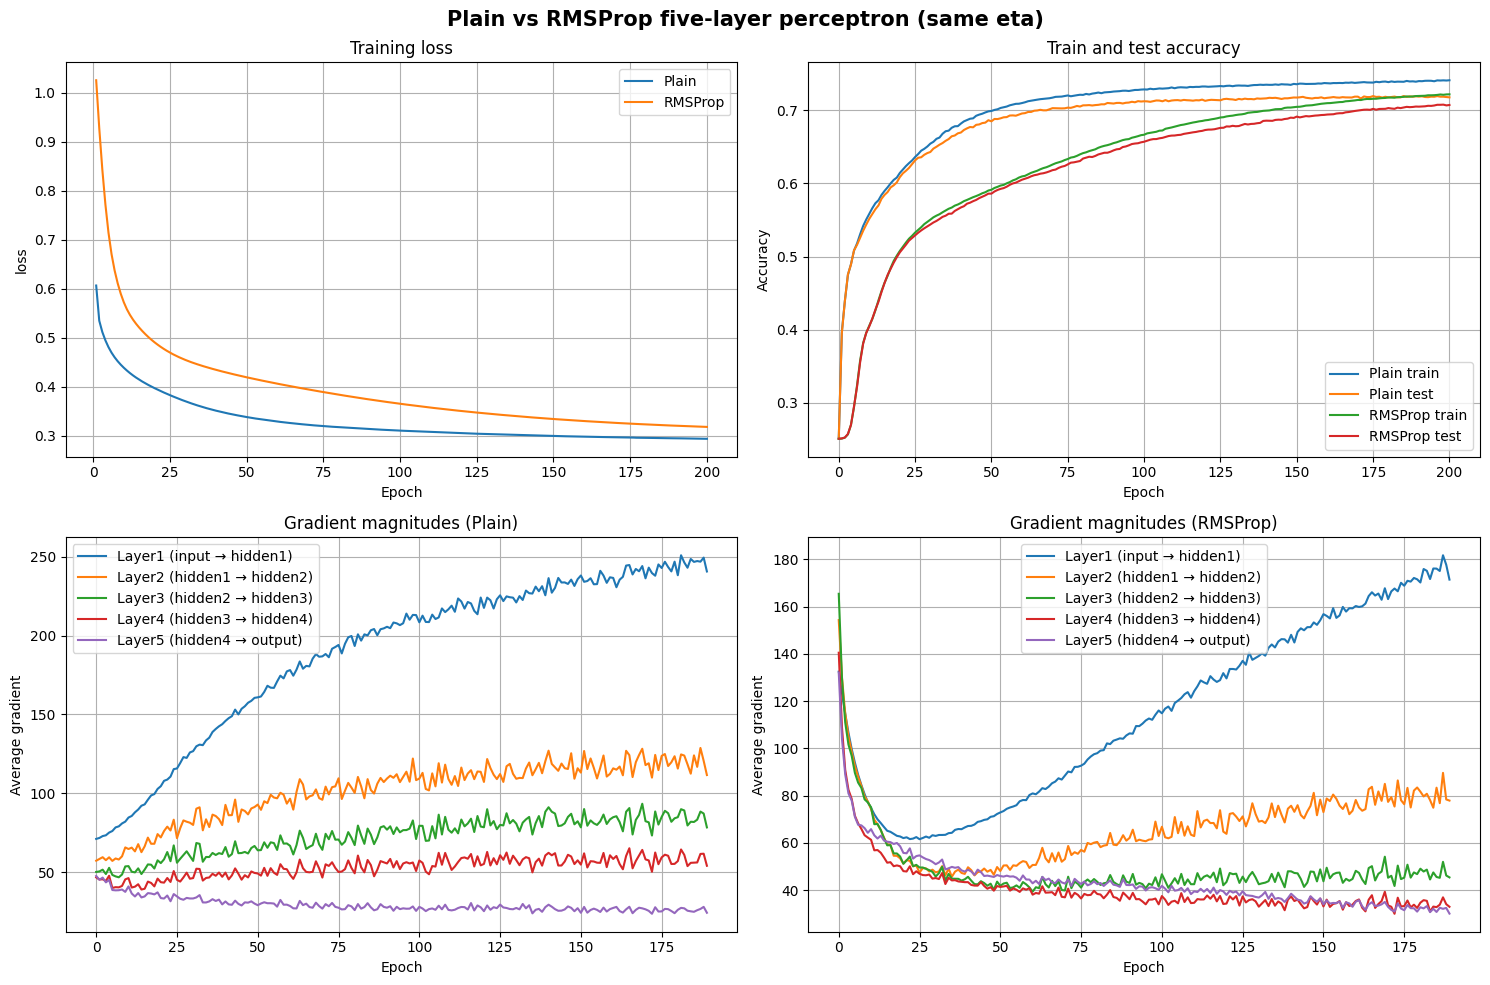

In [20]:
# modeling and visualization, five-layer perceptron with RMSProp, using same eta

import time

# train
nn5_rms_params = dict(
    n_hidden1=50,
    n_hidden2=30,
    n_hidden3=15,
    n_hidden4=8,
    C=0.01,
    epochs=200, # reduced epochs because 200 epochs becomes stable in previous model
    eta=0.0001,
    random_state=42,
    shuffle=True,
    minibatches=50
)

# plain version
plain_model = FiveLayerPerceptron(**nn5_rms_params)
t0 = time.time()
plain_model.fit(X_train_scaled_encoded, y_train, XY_test=(X_test_scaled_encoded, y_test))
plain_time = time.time() - t0

plain_train_acc = accuracy_score(y_train, plain_model.predict(X_train_scaled_encoded))
plain_test_acc  = accuracy_score(y_test,  plain_model.predict(X_test_scaled_encoded))

# RMSProp version
rms_params = dict(nn5_rms_params) # using same parameters
rms_model = FiveLayerPerceptronRMSProp(**rms_params,rms_rho=0.9, rms_eps=1e-7)
t1 = time.time()
rms_model.fit(X_train_scaled_encoded, y_train, XY_test=(X_test_scaled_encoded, y_test))
rms_time = time.time() - t1

rms_train_acc = accuracy_score(y_train, rms_model.predict(X_train_scaled_encoded))
rms_test_acc  = accuracy_score(y_test,  rms_model.predict(X_test_scaled_encoded))

epochs_plain = np.arange(1, len(plain_model.cost_) + 1)
epochs_rms = np.arange(1, len(rms_model.cost_) + 1)


# result summary
print(f"Plain:   Train Accuracy = {plain_train_acc:.4f}, Test Accuracy = {plain_test_acc:.4f}, Time = {plain_time:.2f}s")
print(f"RMSProp: Train Accuracy = {rms_train_acc:.4f}, Test Accuracy = {rms_test_acc:.4f}, Time = {rms_time:.2f}s")



plt.figure(figsize=(15, 10))
plt.suptitle('Plain vs RMSProp five-layer perceptron (same eta)', fontsize=15, fontweight='bold')

# loss
plt.subplot(2, 2, 1)
plt.plot(epochs_plain, plain_model.cost_, label='Plain')
plt.plot(epochs_rms, rms_model.cost_, label='RMSProp')
plt.xlabel('Epoch'); plt.ylabel('loss'); plt.title('Training loss')
plt.grid(True); plt.legend()

# accuracy
plt.subplot(2, 2, 2)
plt.plot(plain_model.score_, label='Plain train')
if hasattr(plain_model, 'val_score_'):
    plt.plot(plain_model.val_score_, label='Plain test')
plt.plot(rms_model.score_, label='RMSProp train')
if hasattr(rms_model, 'val_score_'):
    plt.plot(rms_model.val_score_, label='RMSProp test')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Train and test accuracy')
plt.grid(True); plt.legend()

# gradient magnitudes per layer (plain)
plt.subplot(2, 2, 3)
grad_plain = np.array(plain_model.grad_mags_)
plt.plot(grad_plain[10:, 0], label='Layer1 (input → hidden1)')
plt.plot(grad_plain[10:, 1], label='Layer2 (hidden1 → hidden2)')
plt.plot(grad_plain[10:, 2], label='Layer3 (hidden2 → hidden3)')
plt.plot(grad_plain[10:, 3], label='Layer4 (hidden3 → hidden4)')
plt.plot(grad_plain[10:, 4], label='Layer5 (hidden4 → output)')
plt.xlabel('Epoch')
plt.ylabel('Average gradient')
plt.title('Gradient magnitudes (Plain)')
plt.grid(True)
plt.legend()

# gradient magnitudes per layer (RMSProp)
plt.subplot(2, 2, 4)
grad_rms = np.array(rms_model.grad_mags_)
plt.plot(grad_rms[10:, 0], label='Layer1 (input → hidden1)')
plt.plot(grad_rms[10:, 1], label='Layer2 (hidden1 → hidden2)')
plt.plot(grad_rms[10:, 2], label='Layer3 (hidden2 → hidden3)')
plt.plot(grad_rms[10:, 3], label='Layer4 (hidden3 → hidden4)')
plt.plot(grad_rms[10:, 4], label='Layer5 (hidden4 → output)')
plt.xlabel('Epoch')
plt.ylabel('Average gradient')
plt.title('Gradient magnitudes (RMSProp)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()





**Plain model and RMSProp model comparison, using the same parameters**

While applying the same parameters, with 0.0001 as the eta value on plain and RMSProp models, the RMSProp doesn't perform better than the plain version.

The RMSProp's loss is overall higher, although it decreases sharply at the beginning, which means the plain model achieves faster convergence at this step size. And its accuracy is lower than the plain version. But the overall range of average gradients is lower than the plain version, meaning it's smoother than the plain version. Also, the run time is higher than the plain model. This result may be because in RMSProp we divide the step size by the root of the running average of gradient square and plus the epsilon, the RMSProp becomes more conservative and slower.

So we tried a different eta value.


Plain:   Train Accuracy = 0.7412, Test Accuracy = 0.7178, Time = 182.44s
RMSProp: Train Accuracy = 0.7636, Test Accuracy = 0.7187, Time = 154.91s


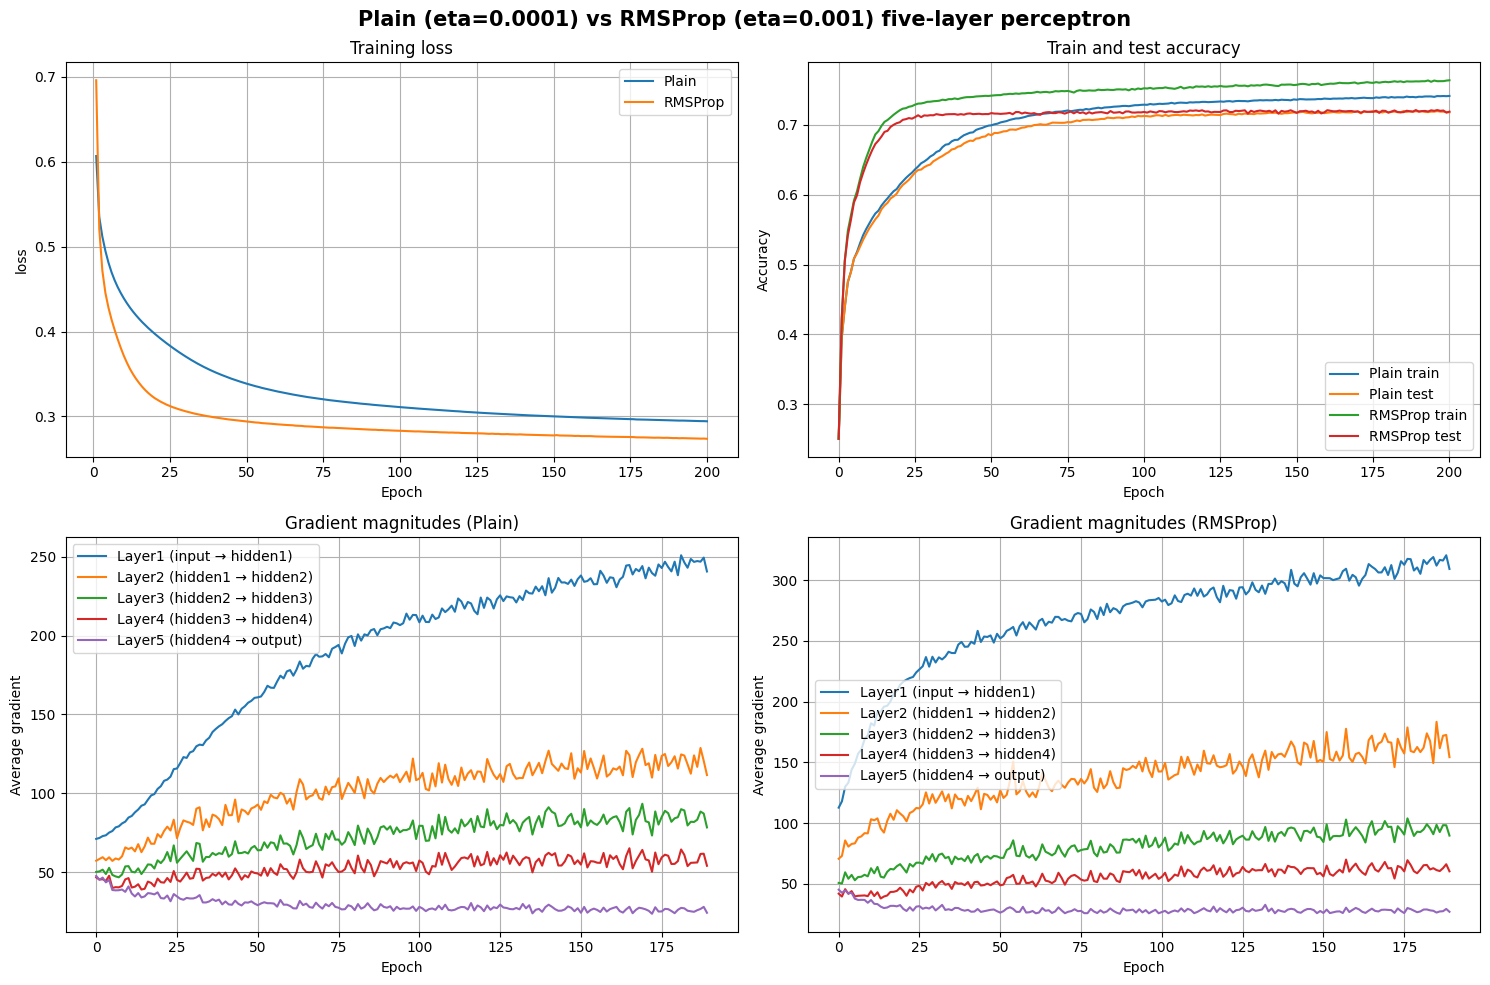

In [21]:
# modeling and visualization, five-layer perceptron with RMSProp, using different eta

import time

# train
nn5_rms_params = dict(
    n_hidden1=50,
    n_hidden2=30,
    n_hidden3=15,
    n_hidden4=8,
    C=0.01,
    epochs=200,
    eta=0.0001,
    random_state=42,
    shuffle=True,
    minibatches=50
)



# plain version
plain_model = FiveLayerPerceptron(**nn5_rms_params)
t0 = time.time()
plain_model.fit(X_train_scaled_encoded, y_train, XY_test=(X_test_scaled_encoded, y_test))
plain_time = time.time() - t0

plain_train_acc = accuracy_score(y_train, plain_model.predict(X_train_scaled_encoded))
plain_test_acc  = accuracy_score(y_test,  plain_model.predict(X_test_scaled_encoded))

# RMSProp version
rms_params = dict(nn5_rms_params, eta=0.001) # different eta here
rms_model = FiveLayerPerceptronRMSProp(**rms_params,rms_rho=0.9, rms_eps=1e-7) 
t1 = time.time()
rms_model.fit(X_train_scaled_encoded, y_train, XY_test=(X_test_scaled_encoded, y_test))
rms_time = time.time() - t1

rms_model_predict_train = rms_model.predict(X_train_scaled_encoded)
rms_model_predict_test = rms_model.predict(X_test_scaled_encoded)

rms_train_acc = accuracy_score(y_train, rms_model_predict_train)
rms_test_acc  = accuracy_score(y_test,  rms_model_predict_test)

epochs_plain = np.arange(1, len(plain_model.cost_) + 1)
epochs_rms = np.arange(1, len(rms_model.cost_) + 1)


# result summary
print(f"Plain:   Train Accuracy = {plain_train_acc:.4f}, Test Accuracy = {plain_test_acc:.4f}, Time = {plain_time:.2f}s")
print(f"RMSProp: Train Accuracy = {rms_train_acc:.4f}, Test Accuracy = {rms_test_acc:.4f}, Time = {rms_time:.2f}s")



plt.figure(figsize=(15, 10))
plt.suptitle('Plain (eta=0.0001) vs RMSProp (eta=0.001) five-layer perceptron', fontsize=15, fontweight='bold')

# loss
plt.subplot(2, 2, 1)
plt.plot(epochs_plain, plain_model.cost_, label='Plain')
plt.plot(epochs_rms, rms_model.cost_, label='RMSProp')
plt.xlabel('Epoch'); plt.ylabel('loss'); plt.title('Training loss')
plt.grid(True); plt.legend()

# accuracy
plt.subplot(2, 2, 2)
plt.plot(plain_model.score_, label='Plain train')
if hasattr(plain_model, 'val_score_'):
    plt.plot(plain_model.val_score_, label='Plain test')
plt.plot(rms_model.score_, label='RMSProp train')
if hasattr(rms_model, 'val_score_'):
    plt.plot(rms_model.val_score_, label='RMSProp test')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Train and test accuracy')
plt.grid(True); plt.legend()

# gradient magnitudes per layer (plain)
plt.subplot(2, 2, 3)
grad_plain = np.array(plain_model.grad_mags_)
plt.plot(grad_plain[10:, 0], label='Layer1 (input → hidden1)')
plt.plot(grad_plain[10:, 1], label='Layer2 (hidden1 → hidden2)')
plt.plot(grad_plain[10:, 2], label='Layer3 (hidden2 → hidden3)')
plt.plot(grad_plain[10:, 3], label='Layer4 (hidden3 → hidden4)')
plt.plot(grad_plain[10:, 4], label='Layer5 (hidden4 → output)')
plt.xlabel('Epoch')
plt.ylabel('Average gradient')
plt.title('Gradient magnitudes (Plain)')
plt.grid(True)
plt.legend()

# gradient magnitudes per layer (RMSProp)
plt.subplot(2, 2, 4)
grad_rms = np.array(rms_model.grad_mags_)
plt.plot(grad_rms[10:, 0], label='Layer1 (input → hidden1)')
plt.plot(grad_rms[10:, 1], label='Layer2 (hidden1 → hidden2)')
plt.plot(grad_rms[10:, 2], label='Layer3 (hidden2 → hidden3)')
plt.plot(grad_rms[10:, 3], label='Layer4 (hidden3 → hidden4)')
plt.plot(grad_rms[10:, 4], label='Layer5 (hidden4 → output)')
plt.xlabel('Epoch')
plt.ylabel('Average gradient')
plt.title('Gradient magnitudes (RMSProp)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

**Plain model and RMSProp model comparison, using the different eta value**

After increasing the eta (learning rate) of RMSProp from 0.0001 to 0.001 (the plain eta is still 0.0001), the performance of RMSProp improves significantly.

The training loss of RMSProp decreases faster than the plain model, and reaches a lower result too, which indicates better convergence with this adjusted step size.

The train and test accuracy also increase faster than the plain model, and the RMSProp train accuracy and test accuracy are both higher than the plain model. But as the epoch grows and reaches about 150, the final test accuracy is almost the same.

The gradient magnitude plots are similar with the different eta value, but the RMSProp maintains smoother and more stable curves, and shows reduced variation in gradient magnitudes across layers, indicating the RMSProp has a more balanced learning across the entire network.

In conclusion, after tuning the leaning rate, RMSProp reaches similar loss and accuracy levels using fewer epochs, which effectively improves training efficiency and convergence speed.

In [22]:
# statistical comparison using McNemar test

print("Comparing mcnemar result between 5 layer plain and RMSRrop")
y_pred_test_plain = plain_model.predict(X_test_scaled_encoded)
y_pred_test_rms   = rms_model.predict(X_test_scaled_encoded)

# construct contingency table
both_correct    = np.sum((y_pred_test_plain == y_test) & (y_pred_test_rms == y_test))
plain_only_correct = np.sum((y_pred_test_plain == y_test) & (y_pred_test_rms != y_test))
rms_only_correct   = np.sum((y_pred_test_plain != y_test) & (y_pred_test_rms == y_test))
both_wrong      = np.sum((y_pred_test_plain != y_test) & (y_pred_test_rms != y_test))

contingency_table = [[both_correct,  plain_only_correct],[rms_only_correct, both_wrong]]


result = mcnemar(contingency_table, exact=True)
print(result)


Comparing mcnemar result between 5 layer plain and RMSRrop
pvalue      0.7548688862804451
statistic   732.0


We performed a McNemar test to statistically compare the prediction results of five-layer plain and RMSProp models on the same test set. And the pvalue is about 0.7549, which is much greater than the 0.05 significance threshold, and statistics is only 732. This statistic comparison indicates these two model doesn't have significant difference in terms of the performance.

## 4. Exceptional Work

In [23]:
#Gpt helped with some debugging
class FiveLayerAdaMPerceptron(FiveLayerPerceptron):
	def __init__(self, n_hidden1=50, n_hidden2=30, n_hidden3=15, n_hidden4=8, C=0, epochs=500, eta=0.001, random_state=None, shuffle=True, minibatches=1, beta1 = 0.9, beta2 = 0.999, eps = 1e-8):
		super().__init__(n_hidden1, n_hidden2, n_hidden3, n_hidden4, C, epochs, eta, random_state, shuffle, minibatches)
		self.beta1 = beta1
		self.beta2 = beta2
		self.eps = eps
		self.k = 0
 	
	def fit(self, X, y, print_progress=False, XY_test=None):
		"""Learn weights from training data with mini-batch"""
		X_data, y_data = X.copy(), y.copy()
		X_data = np.array(X_data)
		y_data = np.array(y_data)
		Y_enc = self._encode_labels(y)
		
		# Init weights and setup matrices
		self.n_features_ = X_data.shape[1]
		self.n_output_ = Y_enc.shape[0]

		if not hasattr(self, 'W1'):
			(self.W1, self.W2, self.W3, self.W4, self.W5,
			self.b1, self.b2, self.b3, self.b4, self.b5) = self._initialize_weights()

		self.cost_ = []
		self.score_ = []
		self.score_.append(accuracy_score(y_data, self.predict(X_data)))
		self.grad_mags_ = []
		
		# Keep track of validation, if given
		if XY_test is not None:
			X_test = XY_test[0].copy()
			y_test = XY_test[1].copy()
			self.val_score_ = []
			self.val_score_.append(accuracy_score(y_test, self.predict(X_test)))
			
		for i in range(self.epochs):
			if print_progress > 0 and (i + 1) % print_progress == 0:
				sys.stderr.write('\rEpoch: %d/%d' % (i + 1, self.epochs))
				sys.stderr.flush()

			if self.shuffle:
				idx_shuffle = np.random.permutation(y_data.shape[0])
				X_data, Y_enc, y_data = X_data[idx_shuffle], Y_enc[:, idx_shuffle], y_data[idx_shuffle]

			mini = np.array_split(range(y_data.shape[0]), self.minibatches)
			mini_cost = []
			epoch_grad_W1, epoch_grad_W2, epoch_grad_W3, epoch_grad_W4, epoch_grad_W5 = [], [], [], [], []
			
			for idx in mini:
				self.k += 1 #Adding updated iteration
				# Feedforward
				A1, Z1, A2, Z2, A3, Z3, A4, Z4, A5, Z5, A6 = self._feedforward(X_data[idx], self.W1,
														 self.W2, self.W3, self.W4, self.W5, self.b1, self.b2, self.b3, self.b4, self.b5)

				cost = self._cost(A6, Y_enc[:, idx], self.W1, self.W2, self.W3, self.W4, self.W5)
				mini_cost.append(cost)
				
				# Compute gradient via backpropagation
				gradW1, gradW2, gradW3, gradW4, gradW5, gradb1, gradb2, gradb3, gradb4, gradb5 = self._get_gradient(
					A1=A1, A2=A2, A3=A3, A4=A4, A5=A5, A6=A6,
					Z1=Z1, Z2=Z2, Z3=Z3, Z4=Z4, Z5=Z5,
					Y_enc=Y_enc[:, idx], 
					W1=self.W1, W2=self.W2, W3=self.W3, W4=self.W4, W5=self.W5
				)
				
								# Record gradient magnitudes
				epoch_grad_W1.append(np.linalg.norm(gradW1))
				epoch_grad_W2.append(np.linalg.norm(gradW2))
				epoch_grad_W3.append(np.linalg.norm(gradW3))
				epoch_grad_W4.append(np.linalg.norm(gradW4))
				epoch_grad_W5.append(np.linalg.norm(gradW5))

				# Update all W and b values
				self._update_parameters(self.eta, gradW1, gradW2, gradW3, gradW4, gradW5, gradb1, gradb2, gradb3, gradb4, gradb5)

			self.cost_.append(np.mean(mini_cost))
			self.score_.append(accuracy_score(y_data, self.predict(X_data)))
			
			self.grad_mags_.append((
				np.mean(epoch_grad_W1),
				np.mean(epoch_grad_W2),
				np.mean(epoch_grad_W3),
				np.mean(epoch_grad_W4),
				np.mean(epoch_grad_W5)))
	
			# Update if a validation set was provided
			if XY_test is not None:
				yhat = self.predict(X_test)
				self.val_score_.append(accuracy_score(y_test, yhat))
			
		return self
	
	def _initialize_weights(self):
		"""Initialize weights Glorot and He normalization."""
		init_bound = 4*np.sqrt(6. / (self.n_hidden1 + self.n_features_))
		W1 = np.random.uniform(-init_bound, init_bound, (self.n_hidden1, self.n_features_))
		self.mW1 = np.zeros_like(W1)

		init_bound = 4*np.sqrt(6. / (self.n_hidden2 + self.n_hidden1))
		W2 = np.random.uniform(-init_bound, init_bound, (self.n_hidden2, self.n_hidden1))
		self.mW2 = np.zeros_like(W2)

		init_bound = 4*np.sqrt(6. / (self.n_hidden3 + self.n_hidden2))
		W3 = np.random.uniform(-init_bound, init_bound, (self.n_hidden3, self.n_hidden2))
		self.mW3 = np.zeros_like(W3)

		init_bound = 4*np.sqrt(6. / (self.n_hidden4 + self.n_hidden3))
		W4 = np.random.uniform(-init_bound, init_bound, (self.n_hidden4, self.n_hidden3))
		self.mW4 = np.zeros_like(W4)

		init_bound = 4*np.sqrt(6. / (self.n_output_ + self.n_hidden4))
		W5 = np.random.uniform(-init_bound, init_bound, (self.n_output_, self.n_hidden4))
		self.mW5 = np.zeros_like(W5)

		self.vW1 = np.zeros_like(W1)
		self.vW2 = np.zeros_like(W2)
		self.vW3 = np.zeros_like(W3)
		self.vW4 = np.zeros_like(W4)
		self.vW5 = np.zeros_like(W5)

		b1 = np.zeros((self.n_hidden1, 1))
		self.mb1 = np.zeros_like(b1)
		self.vb1 = np.zeros_like(b1)
		b2 = np.zeros((self.n_hidden2, 1))
		self.mb2 = np.zeros_like(b2)
		self.vb2 = np.zeros_like(b2)
		b3 = np.zeros((self.n_hidden3, 1))
		self.mb3 = np.zeros_like(b3)
		self.vb3 = np.zeros_like(b3)
		b4 = np.zeros((self.n_hidden4, 1))
		self.mb4 = np.zeros_like(b4)
		self.vb4 = np.zeros_like(b4)
		b5 = np.zeros((self.n_output_, 1)) - 2.0 # add b5
		self.mb5 = np.zeros_like(b5)
		self.vb5 = np.zeros_like(b5)

		return W1, W2, W3, W4, W5, b1, b2, b3, b4, b5
	
	def _update_parameters(self, eta, gradW1, gradW2, gradW3, gradW4, gradW5, gradb1, gradb2, gradb3, gradb4, gradb5):
		"""Update weights using Adam"""
		#accumulated gradient
		self.mW1 = self.beta1 * self.mW1 + (1 - self.beta1) * gradW1
		self.mW2 = self.beta1 * self.mW2 + (1 - self.beta1) * gradW2
		self.mW3 = self.beta1 * self.mW3 + (1 - self.beta1) * gradW3
		self.mW4 = self.beta1 * self.mW4 + (1 - self.beta1) * gradW4
		self.mW5 = self.beta1 * self.mW5 + (1 - self.beta1) * gradW5

		self.mb1 = self.beta1 * self.mb1 + (1 - self.beta1) * gradb1
		self.mb2 = self.beta1 * self.mb2 + (1 - self.beta1) * gradb2
		self.mb3 = self.beta1 * self.mb3 + (1 - self.beta1) * gradb3
		self.mb4 = self.beta1 * self.mb4 + (1 - self.beta1) * gradb4
		self.mb5 = self.beta1 * self.mb5 + (1 - self.beta1) * gradb5

		#Accumulate squared gradient
		self.vW1 = self.beta2 * self.vW1 + (1 - self.beta2) * (gradW1 ** 2)
		self.vW2 = self.beta2 * self.vW2 + (1 - self.beta2) * (gradW2 ** 2)
		self.vW3 = self.beta2 * self.vW3 + (1 - self.beta2) * (gradW3 ** 2)
		self.vW4 = self.beta2 * self.vW4 + (1 - self.beta2) * (gradW4 ** 2)
		self.vW5 = self.beta2 * self.vW5 + (1 - self.beta2) * (gradW5 ** 2)

		self.vb1 = self.beta2 * self.vb1 + (1 - self.beta2) * (gradb1 ** 2)
		self.vb2 = self.beta2 * self.vb2 + (1 - self.beta2) * (gradb2 ** 2)
		self.vb3 = self.beta2 * self.vb3 + (1 - self.beta2) * (gradb3 ** 2)
		self.vb4 = self.beta2 * self.vb4 + (1 - self.beta2) * (gradb4 ** 2)
		self.vb5 = self.beta2 * self.vb5 + (1 - self.beta2) * (gradb5 ** 2)

		#Boost moments
		mW1_hat = self.mW1 / (1 - self.beta1 ** self.k)
		mW2_hat = self.mW2 / (1 - self.beta1 ** self.k)
		mW3_hat = self.mW3 / (1 - self.beta1 ** self.k)
		mW4_hat = self.mW4 / (1 - self.beta1 ** self.k)
		mW5_hat = self.mW5 / (1 - self.beta1 ** self.k)

		mb1_hat = self.mb1 / (1 - self.beta1 ** self.k)
		mb2_hat = self.mb2 / (1 - self.beta1 ** self.k)
		mb3_hat = self.mb3 / (1 - self.beta1 ** self.k)
		mb4_hat = self.mb4 / (1 - self.beta1 ** self.k)
		mb5_hat = self.mb5 / (1 - self.beta1 ** self.k)

		vW1_hat = self.vW1 / (1 - self.beta2 ** self.k)
		vW2_hat = self.vW2 / (1 - self.beta2 ** self.k)
		vW3_hat = self.vW3 / (1 - self.beta2 ** self.k)
		vW4_hat = self.vW4 / (1 - self.beta2 ** self.k)
		vW5_hat = self.vW5 / (1 - self.beta2 ** self.k)

		vb1_hat = self.vb1 / (1 - self.beta2 ** self.k)
		vb2_hat = self.vb2 / (1 - self.beta2 ** self.k)
		vb3_hat = self.vb3 / (1 - self.beta2 ** self.k)
		vb4_hat = self.vb4 / (1 - self.beta2 ** self.k)
		vb5_hat = self.vb5 / (1 - self.beta2 ** self.k)

		#Update gradient, and normalized
		self.W1 -= self.eta * mW1_hat / (np.sqrt(vW1_hat) + self.eps)
		self.W2 -= self.eta * mW2_hat / (np.sqrt(vW2_hat) + self.eps)
		self.W3 -= self.eta * mW3_hat / (np.sqrt(vW3_hat) + self.eps)
		self.W4 -= self.eta * mW4_hat / (np.sqrt(vW4_hat) + self.eps)
		self.W5 -= self.eta * mW5_hat / (np.sqrt(vW5_hat) + self.eps)

		self.b1 -= self.eta * mb1_hat / (np.sqrt(vb1_hat) + self.eps)
		self.b2 -= self.eta * mb2_hat / (np.sqrt(vb2_hat) + self.eps)
		self.b3 -= self.eta * mb3_hat / (np.sqrt(vb3_hat) + self.eps)
		self.b4 -= self.eta * mb4_hat / (np.sqrt(vb4_hat) + self.eps)
		self.b5 -= self.eta * mb5_hat / (np.sqrt(vb5_hat) + self.eps)

Training Accuracy 0.7676625296524221
Testing Accuracy 0.7163778877887789


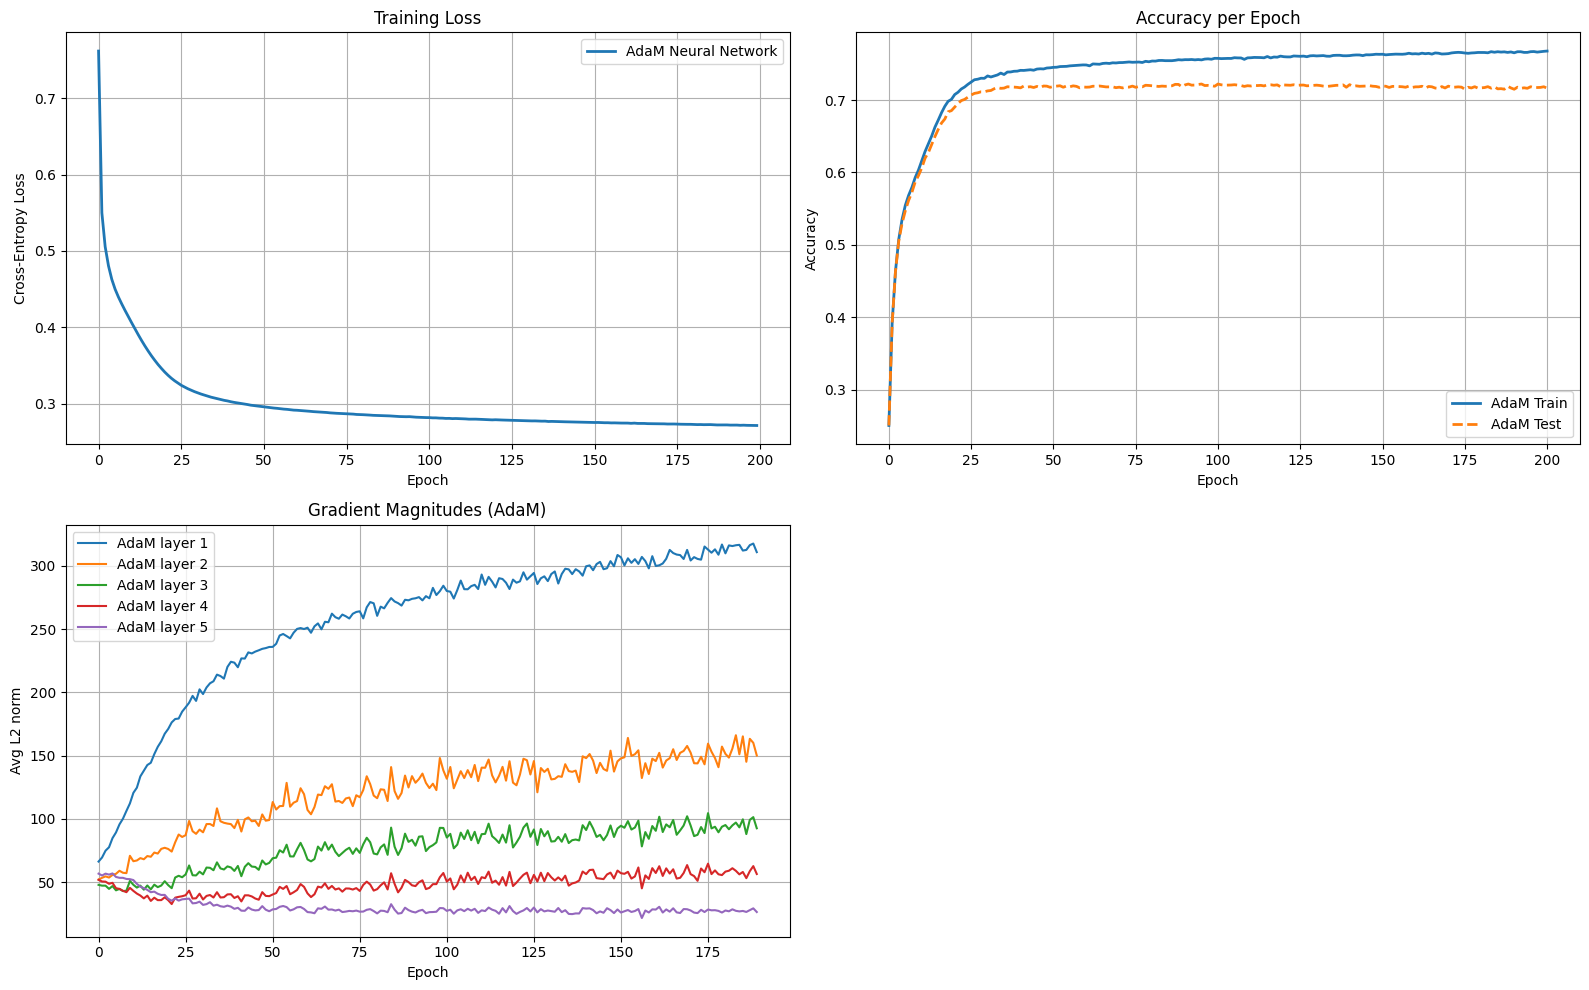

In [24]:
#GPT helped with debugging the 
nn5_adam_params = {
	"n_hidden1":50,
	"n_hidden2":30,
	"n_hidden3":15,
	"n_hidden4":8,
	"C":0.01,
	"epochs":200,
	"eta":0.001,        
	"random_state":42,
	"shuffle":True,
	"minibatches":50
}

adam_nn = FiveLayerAdaMPerceptron(**nn5_adam_params)
adam_nn.fit(X_train_scaled_encoded, y_train, XY_test=(X_test_scaled_encoded, y_test))

adam_predict_train = adam_nn.predict(X_train_scaled_encoded)
adam_predict_test = adam_nn.predict(X_test_scaled_encoded)

adam_nn_acc_train = accuracy_score(y_train, adam_predict_train)
adam_nn_acc_test  = accuracy_score(y_test, adam_predict_test )

print("Training Accuracy", adam_nn_acc_train)
print("Testing Accuracy", adam_nn_acc_test)

plt.figure(figsize=(16, 10))

# (A) Loss
plt.subplot(2, 2, 1)
plt.plot(adam_nn.cost_, label='AdaM Neural Network', linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Cross-Entropy Loss'); plt.title('Training Loss')
plt.grid(True)
plt.legend()

# (B) Accuracy (Train vs Test)
plt.subplot(2, 2, 2)
plt.plot(adam_nn.score_, label='AdaM Train', linewidth=2)
if hasattr(adam_nn, 'val_score_'):
	plt.plot(adam_nn.val_score_, label='AdaM Test', linewidth=2, linestyle='--')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy per Epoch')
plt.grid(True)
plt.legend()

# (C) Gradient norms per layer (AdaM)
plt.subplot(2, 2, 3)
g_rms = np.array(adam_nn.grad_mags_)
g_rms = g_rms[10:]
for i, name in enumerate(['layer 1','layer 2','layer 3','layer 4','layer 5']):
	if g_rms.shape[1] > i:
		plt.plot(g_rms[:, i], label=f'AdaM {name}')
plt.xlabel('Epoch'); plt.ylabel('Avg L2 norm'); plt.title('Gradient Magnitudes (AdaM)')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
#Mcnemar test between AdAm and 5 layer
print("Comparing mcnemar result between 5 layer, and Adam")
both_correct = np.sum((adam_predict_test == y_test) & (y_pred_test == y_test))
outer_model_correct = np.sum((adam_predict_test == y_test) & (y_pred_test != y_test))
inner_model_correct = np.sum((adam_predict_test != y_test) & (y_pred_test == y_test))
both_wrong = np.sum((adam_predict_test != y_test) & (y_pred_test != y_test))

contingency_table = [[both_correct, outer_model_correct],
											[inner_model_correct, both_wrong]]

result = mcnemar(contingency_table, exact=True)
print(result)

print("Comparing mcnemar result between 5 layer with RMS, and Adam")
both_correct = np.sum((adam_predict_test == y_test) & (rms_test_acc == y_test))
outer_model_correct = np.sum((adam_predict_test == y_test) & (rms_test_acc != y_test))
inner_model_correct = np.sum((adam_predict_test != y_test) & (rms_test_acc == y_test))
both_wrong = np.sum((adam_predict_test != y_test) & (rms_test_acc != y_test))

contingency_table = [[both_correct, outer_model_correct],
											[inner_model_correct, both_wrong]]

result = mcnemar(contingency_table, exact=True)
print(result)

Comparing mcnemar result between 5 layer, and Adam
pvalue      0.025403469497167906
statistic   697.0
Comparing mcnemar result between 5 layer with RMS, and Adam
pvalue      0.0
statistic   0.0


#### AdaM Analysis

After adding AdaM to the 5 layer network, it achieved a 78% training accuracy, and a 71% testing accuracy, showing that the model is not being trained specifically to the training dataset (overfitting). In addition, the Gradient Magnitudes graphs shows AdaM prevent vanishing gradient issue, as all the layers are not near the zero value. In addition, the stable gradient, and smooth convergence shows that it has a balance gradient updates across the layers. 

#### Comparing AdaM, and 5 Layer

AdaM outperforms the 5 layer perceptron. Adam was able to converged around 100 epochs compare to 300 epochs for the 5 layer. While the test accuracy is slightly lower for adam by 1%, it is negligible. However, the most crucial difference is in how the gradients across the 5 layers in both the model. Adam showed a smooth gradient curve while the 5 layer perceptron was fluctuating across all the layers, indicating that there is a vanishing gradient issue due to the unbalance updates over the training time. In addition to these, we also compared how different the model is to one another. McNemar test shows that the model is indeed different from one another with a p value of 5.3 x10-5, and a chi square of 814. 

#### Comparing AdaM, and RMSprops

AdaM and RMSprops both uses adaptive learning rate with one another from the gradient graph, we can see that AdaM and RMS Props both have similar gradient curve (despite looking different as AdaM starts with 800 value which hides the uneven graph compared to RMS). This indicates that both models have a healthy gradient, and both also looks like it is preventing the vanishing gradient problem. While the testing accuracy are almost similar, AdaM was able to converged about the same as RMS props as both of them take large steps towards the goal, and slows down , and smaller steps near the goal which allows AdaM to reach the goal state quicker. From the McNemar test surprising it shows the model are the same despite having different accuracy test. 

Looks like AdaM is not significantly better than RMS promps, as from the graphs AdaM, and RMSprops looks to be near identical, which is also supported by the McNemars result as well. 


## 5. Conclusion

1. Data preparation is important, which can directly influence the accuracy performance.
2. Adding more layers does not seem to improve the test accuracy performance of the model.
3. Using any of the adaptive learning rate improves our training time over a smaller epochs compare to a model not using an adaptive learning rate, and the overall test accuracy remains almost the same.